# Licenciatura en Ciencia de Datos
## Calidad y Preprocesamiento de Datos

---

### **Proyecto Final:**

**Equipo**

**Castrillo Cruz Karen Arlet**
**Pérez Aguiar Oropeza Gabriel Emiliano**
**Ramos González Nadia**
**Rueda Reyes Fabián**
**Torres Pasión Angel Isaac**

### **Objetivo**

Producir una versión completa, limpia y deduplicada del Registro Nacional de Personas Sancionadas del INE, utilizando la base de datos de violencia familiar BANAVIM como fuente complementaria, para construir un perfil estadístico integrado de la violencia por municipio y estado en México (2020–2022).

## 0. Ingesta de Datos

In [1]:
# Instalación de dependencias (ejecutar una sola vez)
!pip install recordlinkage fuzzywuzzy python-Levenshtein jellyfish \
            unidecode networkx ftfy geopy openpyxl ydata-profiling --quiet

In [2]:
import pandas as pd
import numpy as np
import re
import pickle
import json as _json
from pathlib import Path
from unicodedata import normalize

import jellyfish
from unidecode import unidecode
import recordlinkage
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style='whitegrid')

print('Entorno listo')

Entorno listo


In [3]:
# Rutas base — funciona en Windows y Linux/macOS
DATA_DIR = Path('..') / 'Data'
PKL_DIR  = Path('.')   # los pkl viven en el mismo directorio que el notebook

DATA_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR / 'fusion_outputs').mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR.resolve())
print('PKL_DIR :', PKL_DIR.resolve())

DATA_DIR: /home/emi/Desktop/Calidad-y-Preprocesamiento-de-Datos---Registro-Publico-de-Agresores/Data
PKL_DIR : /home/emi/Desktop/Calidad-y-Preprocesamiento-de-Datos---Registro-Publico-de-Agresores/Código


In [4]:
# 0.1 INE — Registro Nacional de Personas Sancionadas
df_ine_raw = pd.read_excel(
    DATA_DIR / 'Registro-nacional-de-personas-sancionadas (INE).xlsx'
)
df_ine_raw.columns = df_ine_raw.columns.str.strip()
print(f'INE crudo: {df_ine_raw.shape}')

# 0.2 BANAVIM — desde pkl pregenerados para evitar parsear los Excel originales
# Si los pkl no existen, descomentar leer_banavim_agresores() y generarlos.
def leer_banavim_agresores(path: Path, año: int) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=f'AGRESORES {año}', header=0)
    df.columns = df.iloc[0]
    df = df.drop(index=0).reset_index(drop=True)
    df.columns = df.columns.str.strip()
    df['año_base'] = año
    return df

# bv_2020 = leer_banavim_agresores(DATA_DIR / '2020.xlsx', 2020)
# bv_2021 = leer_banavim_agresores(DATA_DIR / '2021.xlsx', 2021)
# bv_2022 = leer_banavim_agresores(DATA_DIR / '2022.xlsx', 2022)

for año in [2020, 2021, 2022]:
    with open(PKL_DIR / f'bv_{año}.pkl', 'rb') as f:
        globals()[f'bv_{año}'] = pickle.load(f)
    print(f'BANAVIM {año}: {globals()[f"bv_{año}"].shape}')

INE crudo: (530, 25)
BANAVIM 2020: (265760, 28)
BANAVIM 2021: (285984, 28)
BANAVIM 2022: (254348, 28)


In [5]:
# Vista previa
print('INE (últimas 5 filas)')
display(df_ine_raw.tail(5))
print('BANAVIM 2020 (primeras 3 filas)')
display(bv_2020.head(3))

INE (últimas 5 filas)


,Nombre,"Calidad, cargo o profesión del sujeto infractor",Sexo,Ámbito Territorial,Entidad Federativa,Municipio,Número De Expediente,Relación Con La Víctima,Incidencia,Órgano Resolutor,Fecha De La Resolución,Conducta,Sanción,Permanencia,Reincidencia De La Conducta,Resolución Penal,Analizó Modo Honesto De Vivir,Cumple Modo Honesto De Vivir,Perteneciente a,Documento Enlace,Enlace Utce Temporalidad,Interseccion de la víctima,Tipo de violencia,Modalidad de violencia,Medidas de reparacion
525,YOLANDA ADELAIDA SANTOS MONTAÑO,NaN,Mujer,Municipal,Oaxaca,San Jacinto Amilpas,JDC/133/2020,Pares,No aplica,TE,11/06/2021,"Negativa a restituir a la víctima en el pleno goce de sus derechos políticos electorales, al omi...",Ninguna,29/09/2027,Sí,No,Sí,No,NaN,https://repositoriodocumental.ine.mx/xmlui/bitstream/handle/123456789/131519/JDC-133-2020-TEEO.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>No lo precisa</element>_x000d_\n...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>Medidas de no repetición</e..."
526,YOLANDA ADELAIDA SANTOS MONTAÑO,NaN,Mujer,Municipal,Oaxaca,San Jacinto Amilpas,JDC/143/2020,Pares,No aplica,TE,11/06/2021,Omisión de pago de dietas a la víctima y de convocarla a sesiones de cabildo,Ninguna,29/09/2027,Sí,No,Sí,No,NaN,https://repositoriodocumental.ine.mx/xmlui/bitstream/handle/123456789/131520/JDC-143-2020-TEEO.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>No lo precisa</element>_x000d_\n...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>Medidas de no repetición</e..."
527,YOLANDA ADELAIDA SANTOS MONTAÑO,NaN,Mujer,Municipal,Oaxaca,San Jacinto Amilpas,SUP-REC-117/2022,Pares,"Pérdida del modo honesto de vivir para los próximos procesos electorales federales, locales y mu...",TEPJF SS,04/05/2022,Revictimización derivada del incumplimiento de las medidas ordenadas ante la existencia de la VP...,Perdida del modo honesto de vivir,05/05/2028,Sí,No,Sí,No,NaN,https://repositoriodocumental.ine.mx/xmlui/bitstream/handle/123456789/134552/SUP-REC-117-2022.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>No lo precisa</element>_x000d_\n...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>No impone</element>_x000d_\..."
528,YOSHIO CÉSAR RAMÍREZ CASTILLO,NaN,Hombre,Municipal,Oaxaca,Ocotlán de Morelos,JDC/05/2024 Y JDC/96/2024 ACUMULADOS,Pares,No aplica,TE,20/09/2024,"Conducta consistente en limitar el acceso a la información financiera, además de no proporcionar...",Amonestación pública,2029-06-04T00:00:00,No,No,No,NaN,NaN,https://teeo.mx/images/sentencias/JDC-05-2024-1.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>Verbal</element>_x000d_\n <elem...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>Disculpa pública</element>_..."
529,YURIDIA PINEDA ORDAZ,NaN,Mujer,Municipal,Oaxaca,El Espinal,JDC/797/2022,Pares,No aplica,TE,08/02/2023,"Invisibilizar a la víctima al limitarla de proporcionarle materiales de oficina, documentación y...",Ninguna,2029-06-01T00:00:00,Sí,No,Sí,Sí,NaN,https://teeo.mx/images/sentencias/JDC-797-2022.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>Psicológica</element>_x000d_\n ...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>Disculpa pública</element>_..."


BANAVIM 2020 (primeras 3 filas)


,Identificador Único,Edad del Agresor,Sexo,Escolaridad,Estado Civil,Fecha de registro,Estado donde reside,Municipio donde reside,Relación o vículo con la víctima,Conoce al Agresor,Durante la agresión efectos droga,Cual Droga,Droga_Alcohol,Droga_DrogaPorIndicación Médica,Droga_Drogas Ilegales,La Consume Manera Cotidiana,Posee_algun tipo de arma,Portaba Dicha Arma,Chacos,Macanas,OtraArmaBlanca,ObjetoPunzoCortante,Machete,Proyectil,ArmaFuegoCorta,ArmaFuegoLarga,OtraFuegoLarga,año_base
0,0128900022-2,34,Hombre,No identificado,NaN,2020-09-03 08:59:29,Aguascalientes,Aguascalientes,Ex pareja,SI,SE DESCONOCE,NaN,0,0,0,NaN,SE DESCONOCE,NaN,0,0,0,0,0,0,0,0,0,2020
1,0128900106-2,50,Hombre,No identificado,NaN,2020-10-20 09:25:05,Aguascalientes,Aguascalientes,CÃ³nyuge o pareja,SI,SE DESCONOCE,NaN,0,0,0,NaN,SE DESCONOCE,NaN,0,0,0,0,0,0,0,0,0,2020
2,0128900132-2,58,Hombre,No identificado,UniÃ³n libre,2020-07-02 08:07:24,Aguascalientes,Aguascalientes,CÃ³nyuge o pareja,SI,SE DESCONOCE,NaN,0,0,0,NaN,SE DESCONOCE,NaN,0,0,0,0,0,0,0,0,0,2020


## 1. Perfilado

Exploramos los datos crudos antes de cualquier transformación.

### 1.1 Base INE

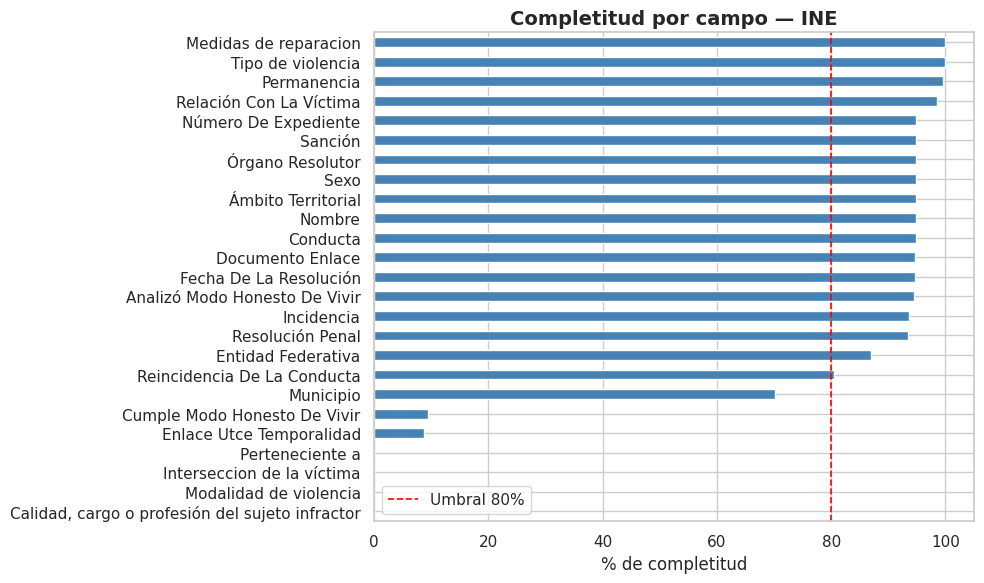

Columnas con <20% completitud (candidatas a descarte):
Calidad, cargo o profesión del sujeto infractor    0.000000
Perteneciente a                                    0.000000
Modalidad de violencia                             0.000000
Interseccion de la víctima                         0.000000
Enlace Utce Temporalidad                           8.679245
Cumple Modo Honesto De Vivir                       9.433962


In [6]:
# 1.1 Completitud INE
completitud_ine = (1 - df_ine_raw.isnull().mean()) * 100

fig, ax = plt.subplots(figsize=(10, 6))
completitud_ine.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Completitud por campo — INE', fontsize=14, fontweight='bold')
ax.set_xlabel('% de completitud')
ax.axvline(80, color='red', linestyle='--', linewidth=1.2, label='Umbral 80%')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Columnas con <20% completitud (candidatas a descarte):')
print(completitud_ine[completitud_ine < 20].sort_values().to_string())

In [7]:
# 1.2 Duplicados exactos por Nombre
dup_nombres = df_ine_raw[
    df_ine_raw['Nombre'].notna() &
    df_ine_raw['Nombre'].duplicated(keep=False)
]
print(f'Registros con nombres duplicados: {len(dup_nombres)}')
display(
    dup_nombres.sort_values('Nombre')
    [['Nombre','Número De Expediente','Conducta','Fecha De La Resolución']]
    .head(15)
)

Registros con nombres duplicados: 74


,Nombre,Número De Expediente,Conducta,Fecha De La Resolución
46,ALEJANDRO GARCÍA HERNÁNDEZ,TEV-JDC-7/2025,Conductas encaminadas a entorpecer y demeritar su participación en el ejercicio del cargo de la ...,19/02/2025
47,ALEJANDRO GARCÍA HERNÁNDEZ,TEV-PES-25/2025,"Conductas desplegadas por el infractor al negar la contratación de un auxiliar, así como apoyo j...",10/06/2025
48,ALEJANDRO GARCÍA HERNÁNDEZ,TEV-PES-97/2025,Manifestaciones realizadas en publicaciones con la intención de disminuir las capacidades de la ...,25/02/2026
49,ALEJANDRO GARCÍA HERNÁNDEZ,TEV-PES-258/2025,"Actos que invisibilizan y discriminan a la quejosa, consistentes en la negativa de proporcionarl...",19/03/2026
55,ALEJANDRO SEVILLA TORRES,TEE-PES-60/2024,Publicaciones realizadas en la red social Facebook con la finalidad de desacredita y denigrar a ...,08/05/2025
56,ALEJANDRO SEVILLA TORRES,CLE-POS-022/2019,Publicaciones realizadas en la red social Facebook y en periódicos que utilizan estereotipos dir...,06/05/2021
103,CARLOS MARIO CORNELIO CORNELIO,PES/075/2021,Obstaculizar la entrega de licencia para la separación del cargo de delegada municipal para que ...,31/03/2022
104,CARLOS MARIO CORNELIO CORNELIO,PES/078/2021,Obstaculizar la entrega de licencia para la separación del cargo de delegada municipal para part...,28/02/2022
115,DANIEL LÓPEZ PLATAS,JDCI/48/2024,Acciones y omisiones que tuvieron como efecto directo el menoscabo del ejercicio del cargo de la...,03/12/2024
116,DANIEL LÓPEZ PLATAS,JDCI/73/2023,"Omisión de convocar a la víctima a sesiones de cabildo, obstaculizando su entrada a las oficinas...",20/10/2023


In [8]:
# 1.3 Campos con formatos mixtos
print('Permanencia (top 10 valores)\n')
print(df_ine_raw['Permanencia'].value_counts().head(10).to_string())
print()
print('Tipo de violencia (primeros 3 valores únicos)\n')
for v in df_ine_raw['Tipo de violencia'].dropna().unique()[:3]:
    print(' ', v[:120])
print()
print('Medidas de reparacion (primeros 3 valores únicos)\n')
for v in df_ine_raw['Medidas de reparacion'].dropna().unique()[:3]:
    print(' ', v[:120])

Permanencia (top 10 valores)

Permanencia
Indeterminada          26
07/10/2027             11
2026-10-11T00:00:00    10
15/07/2026              9
2027-03-25T00:00:00     8
2026-09-13T00:00:00     7
20/07/2028              7
2026-07-27T00:00:00     6
2028-04-27T00:00:00     6
2026-07-09T00:00:00     6

Tipo de violencia (primeros 3 valores únicos)

  tipo_conducta null="true"></tipo_conducta
  tipo_conducta type="Collection(Edm.String)">_x000d_
  <element>Simbólica</element>_x000d_
</tipo_conducta
  tipo_conducta type="Collection(Edm.String)">_x000d_
  <element>Simbólica</element>_x000d_
  <element>Psicológica</elemen

Medidas de reparacion (primeros 3 valores únicos)

  medidas_reparacion null="true"></medidas_reparacion
  medidas_reparacion type="Collection(Edm.String)">_x000d_
  <element>Medidas de satisfacción, medidas de restitución</ele
  medidas_reparacion type="Collection(Edm.String)">_x000d_
  <element>Medidas de no repetición</element>_x000d_
  <element


In [9]:
# 1.4 Distribuciones en campos categóricos
print('Campos categóricos con posibles inconsistencias (Top 7):')
for col in ['Sexo', 'Ambito Territorial', 'Sancion', 'Entidad Federativa']:
    col_real = next((c for c in df_ine_raw.columns if c.strip() == col or
                     unidecode(c.strip()) == unidecode(col)), None)
    if col_real:
        print(f'')
        conteo = df_ine_raw[col_real].value_counts(dropna=False)
        print(conteo.head(7).to_string())
        if len(conteo) > 7:
            print(f'... y {len(conteo) - 7} categorías más ocultas.')

Campos categóricos con posibles inconsistencias (Top 7):

Sexo
Hombre    412
Mujer      91
NaN        27

Ámbito Territorial
Municipal    340
Estatal       86
Nacional      77
NaN           27

Sanción
Ninguna                           228
Multa económica                   144
Amonestación pública              100
NaN                                27
Inscripción en el RNPS             25
Multa simbólica                     1
Multa, prisión y  amonestación      1
... y 4 categorías más ocultas.

Entidad Federativa
Oaxaca              143
Veracruz             72
NaN                  69
Chiapas              37
Tabasco              26
Estado de México     22
Guanajuato           20
... y 23 categorías más ocultas.


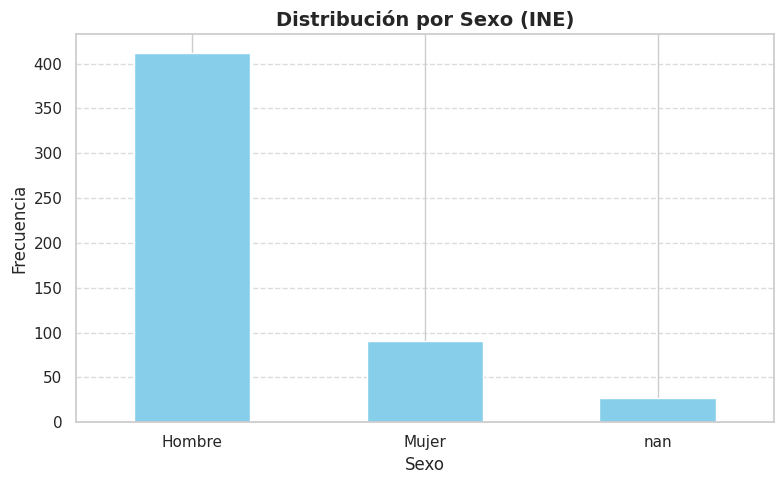

In [10]:
# Distribución: Sexo
plt.figure(figsize=(8, 5))
sexo_counts = df_ine_raw['Sexo'].value_counts(dropna=False)
sexo_counts.plot(kind='bar', color='skyblue')
plt.title('Distribución por Sexo (INE)', fontsize=14, fontweight='bold')
plt.xlabel('Sexo', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

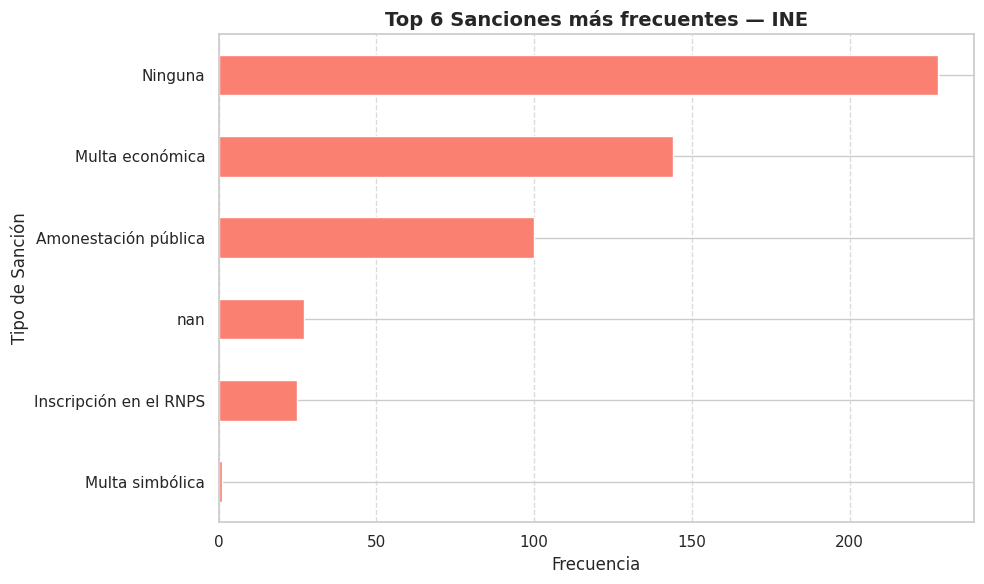

In [11]:
# Distribución: Sanción
plt.figure(figsize=(10, 6))
sancion_counts = df_ine_raw['Sanción'].value_counts(dropna=False).head(6)
sancion_counts.plot(kind='barh', color='salmon')
plt.title('Top 6 Sanciones más frecuentes — INE', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Tipo de Sanción', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

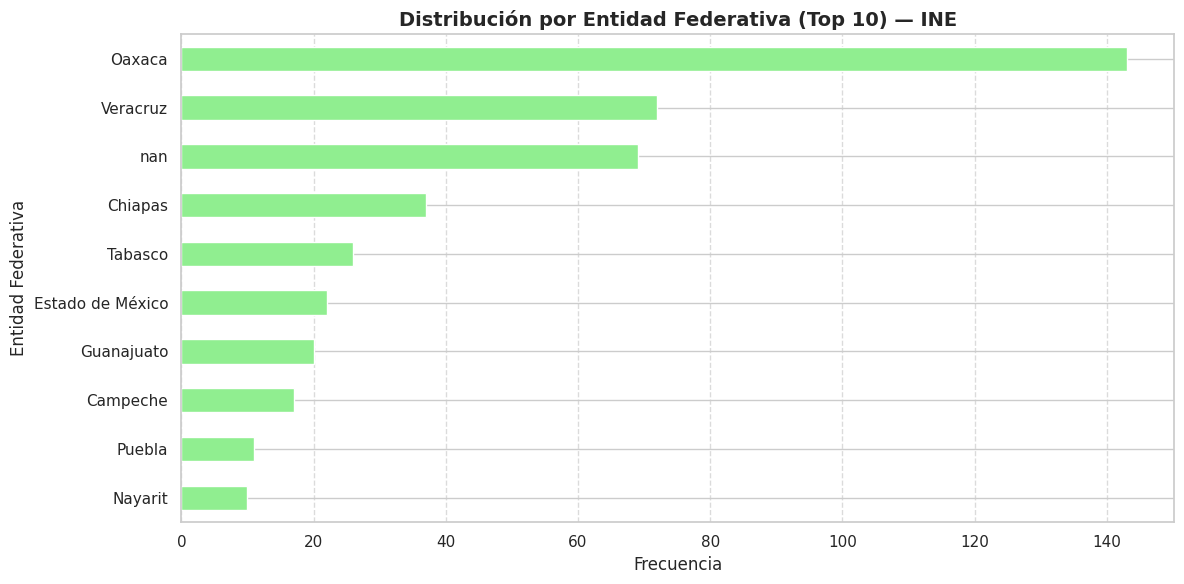

In [12]:
# Distribución: Entidad Federativa
plt.figure(figsize=(12, 6))
entidad_counts = df_ine_raw['Entidad Federativa'].value_counts(dropna=False).head(10)
entidad_counts.plot(kind='barh', color='lightgreen')
plt.title('Distribución por Entidad Federativa (Top 10) — INE', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Entidad Federativa', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Fecha mínima: 2020-11-09 00:00:00 | Fecha máxima: 2026-04-29 00:00:00
Fechas no parseables: 42


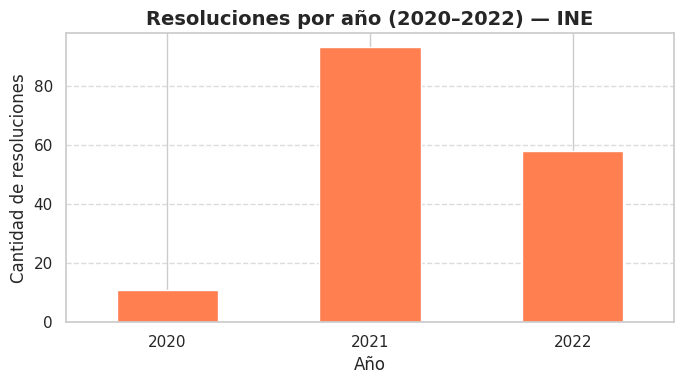

In [13]:
# 1.5 Oportunidad: resoluciones por año (2020-2022)
fechas = pd.to_datetime(df_ine_raw['Fecha De La Resolución'], dayfirst=True, errors='coerce')
print(f'Fecha mínima: {fechas.min()} | Fecha máxima: {fechas.max()}')
print(f'Fechas no parseables: {fechas.isna().sum()}')

conteo_anios = fechas.dropna().dt.year.value_counts().sort_index()
conteo_filtrado = conteo_anios.loc[2020:2022]

plt.figure(figsize=(7, 4))
conteo_filtrado.plot(kind='bar', color='coral')
plt.title('Resoluciones por año (2020–2022) — INE', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de resoluciones', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

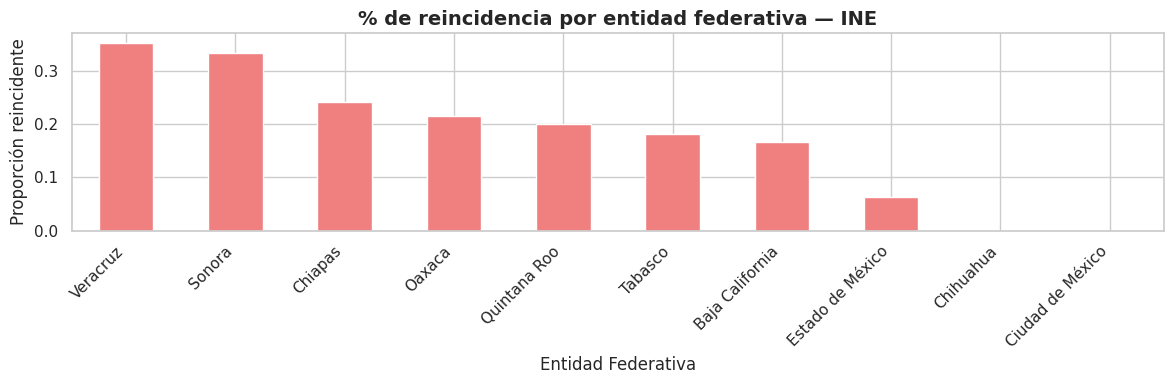

In [14]:
# 1.6 Reincidencia por entidad federativa
reincidencia = (
    df_ine_raw[df_ine_raw['Reincidencia De La Conducta'].notna()]
    .groupby('Entidad Federativa')['Reincidencia De La Conducta']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
col_si = [c for c in reincidencia.columns if str(c).strip().lower() in ('sí','si','yes','1','true')]
if col_si:
    reincidencia[col_si[0]].sort_values(ascending=False).head(10).plot(
        kind='bar', figsize=(12, 4), color='lightcoral', edgecolor='white'
    )
    plt.title('% de reincidencia por entidad federativa — INE', fontsize=14, fontweight='bold')
    plt.ylabel('Proporción reincidente')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Valores únicos en Reincidencia De La Conducta:', df_ine_raw['Reincidencia De La Conducta'].unique())

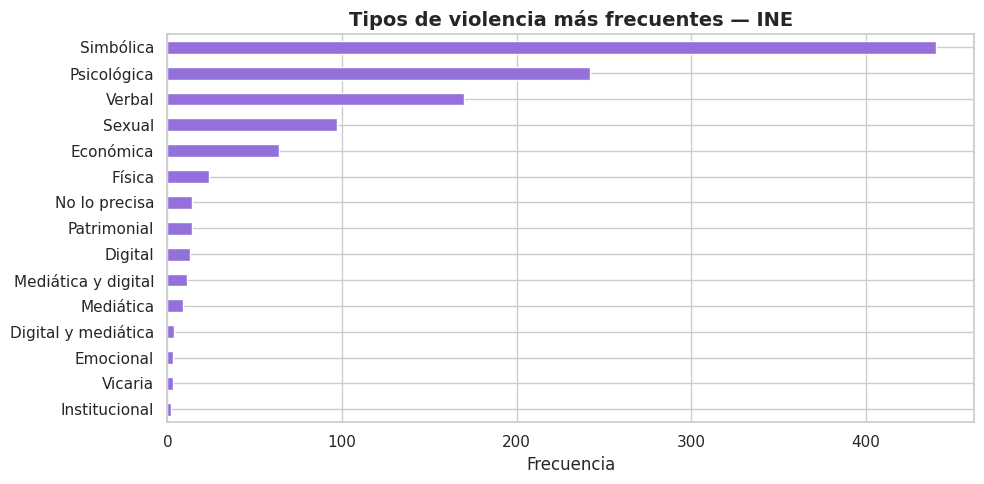

In [15]:
# 1.7 Tipos de violencia más frecuentes (tras parsear el XML)
tipos_raw = df_ine_raw['Tipo de violencia'].dropna()
todos_tipos = []
for val in tipos_raw:
    elementos = re.findall(r'<element>([^<]+)</element>', str(val))
    todos_tipos.extend([e.strip() for e in elementos])

if todos_tipos:
    pd.Series(todos_tipos).value_counts().head(15).sort_values().plot(
        kind='barh', figsize=(10, 5), color='mediumpurple', edgecolor='white'
    )
    plt.title('Tipos de violencia más frecuentes — INE', fontsize=14, fontweight='bold')
    plt.xlabel('Frecuencia')
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron etiquetas <element> en Tipo de violencia')

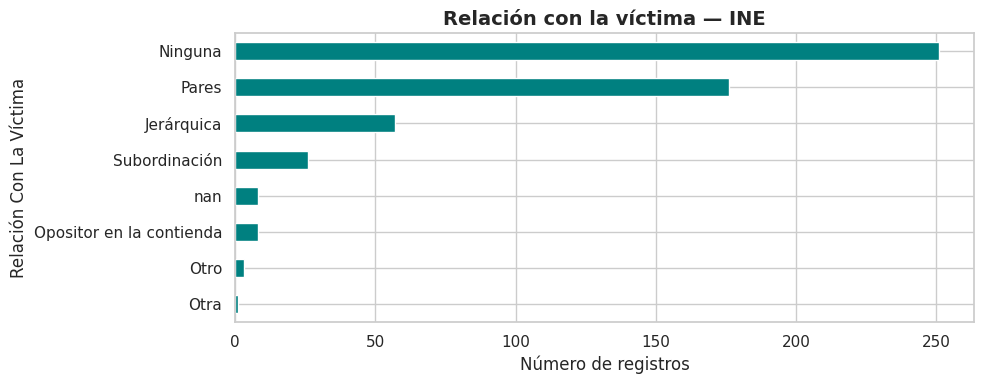

In [16]:
# 1.8 Relación víctima-agresor
fig, ax = plt.subplots(figsize=(10, 4))
(
    df_ine_raw['Relación Con La Víctima']
    .value_counts(dropna=False)
    .head(12)
    .sort_values()
    .plot(kind='barh', ax=ax, color='teal', edgecolor='white')
)
ax.set_title('Relación con la víctima — INE', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de registros')
plt.tight_layout()
plt.show()

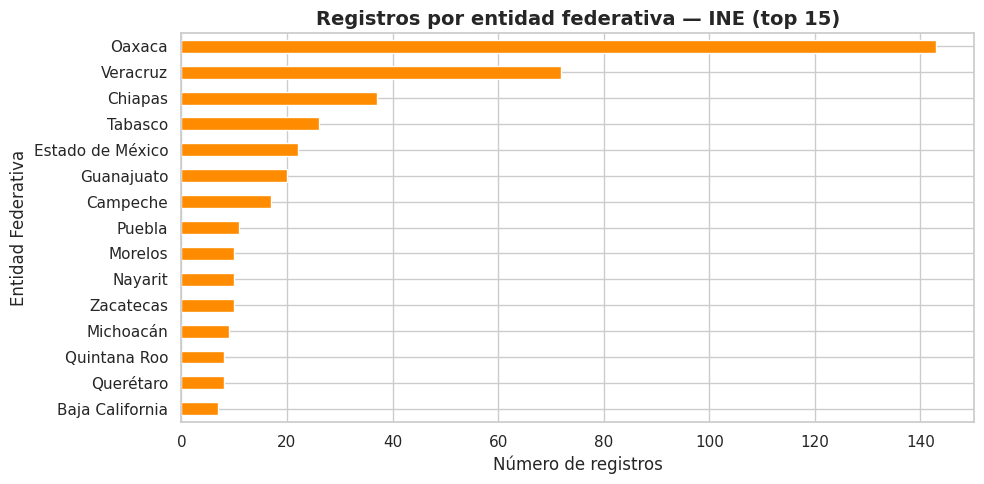

In [17]:
# 1.9 Agresores por entidad federativa (top 15)
fig, ax = plt.subplots(figsize=(10, 5))
(
    df_ine_raw['Entidad Federativa']
    .value_counts()
    .head(15)
    .sort_values()
    .plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
)
ax.set_title('Registros por entidad federativa — INE (top 15)', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de registros')
plt.tight_layout()
plt.show()

### 1.2 Base BANAVIM

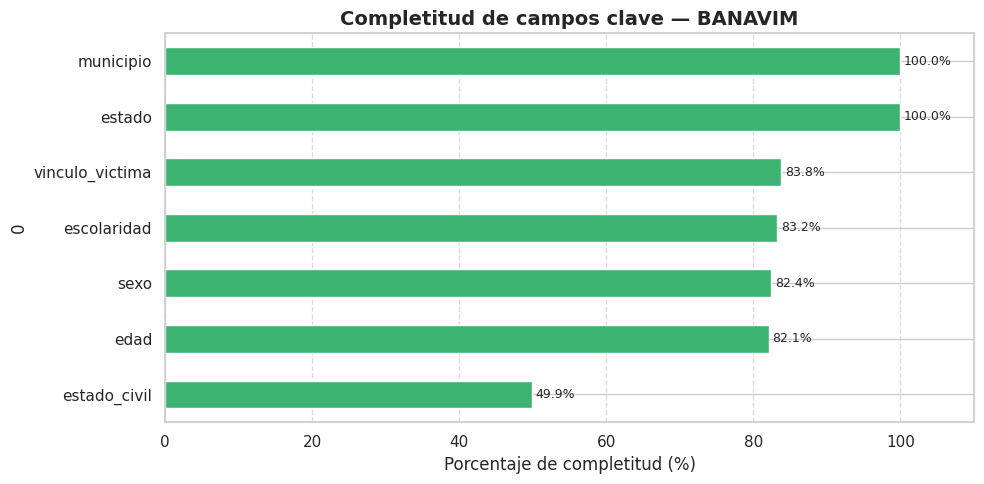

In [18]:
# Concatenación cruda para perfilado (columnas originales, antes de limpieza)
bv_raw = pd.concat([bv_2020, bv_2021, bv_2022], ignore_index=True)

# 1.10 Completitud de campos clave en BANAVIM (nombres originales del Excel)
campos_clave_raw = [
    'Sexo', 'Edad del Agresor', 'Escolaridad', 'Estado Civil',
    'Estado donde reside', 'Municipio donde reside',
    'Relación o vículo con la víctima'
]
etiquetas = [
    'sexo', 'edad', 'escolaridad', 'estado_civil',
    'estado', 'municipio', 'vinculo_victima'
]
completitud_bv = (
    (1 - bv_raw[campos_clave_raw].isnull().mean())
    .mul(100)
    .rename(dict(zip(campos_clave_raw, etiquetas)))
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))
completitud_bv.plot(kind='barh', ax=ax, color='mediumseagreen')
ax.set_title('Completitud de campos clave — BANAVIM', fontsize=14, fontweight='bold')
ax.set_xlabel('Porcentaje de completitud (%)')
ax.set_xlim(0, 110)
ax.grid(axis='x', linestyle='--', alpha=0.7)
for bar in ax.patches:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Total de registros en BANAVIM: 806,092
Registros con Identificador Único duplicado: 78,491 (9.7%)


,Identificador Único,Sexo,Estado donde reside,Relación o vículo con la víctima,año_base
265795,0128800103-1,NaN,Aguascalientes,NaN,2021
265794,0128800103-1,NaN,Aguascalientes,NaN,2021
265804,0128800112-1,Hombre,Aguascalientes,CÃ³nyuge o pareja,2021
265805,0128800112-1,Hombre,Aguascalientes,CÃ³nyuge o pareja,2021
265812,0128800119-1,Hombre,Aguascalientes,Hijo(a),2021
265813,0128800119-1,Hombre,Aguascalientes,CÃ³nyuge o pareja,2021
265814,0128800120-1,Hombre,Aguascalientes,Hermano(a),2021
265815,0128800120-1,NaN,Aguascalientes,NaN,2021
265819,0128800124-1,NaN,Aguascalientes,NaN,2021
265820,0128800124-1,Hombre,Aguascalientes,Madre o padre,2021



Campos con problemas de codificación (mojibake):


,Campo,Registros con mojibake
0,Relación o vículo con la víctima,305694
1,Municipio donde reside,296001
2,Estado donde reside,213569
3,Estado Civil,61713
4,Escolaridad,10943
5,Cual Droga,1634



Campos categóricos con posibles inconsistencias (Top 7):

Escolaridad:
Escolaridad
No identificado    237857
Secundaria         171258
NaN                135372
Preparatoria        87142
Primaria            79091
Licenciatura        48265
Ninguna             22517

Estado Civil:
Estado Civil
NaN                404073
Casado             126165
No identificado     80570
Soltero             75621
UniÃ³n libre        61713
Concubinato         25706
Separado            17533

Conoce al Agresor:
Conoce al Agresor
SI     664302
NO     141786
NaN         4

Posee_algun tipo de arma:
Posee_algun tipo de arma
SE DESCONOCE    377500
NO              375366
SI               52546
NaN                680


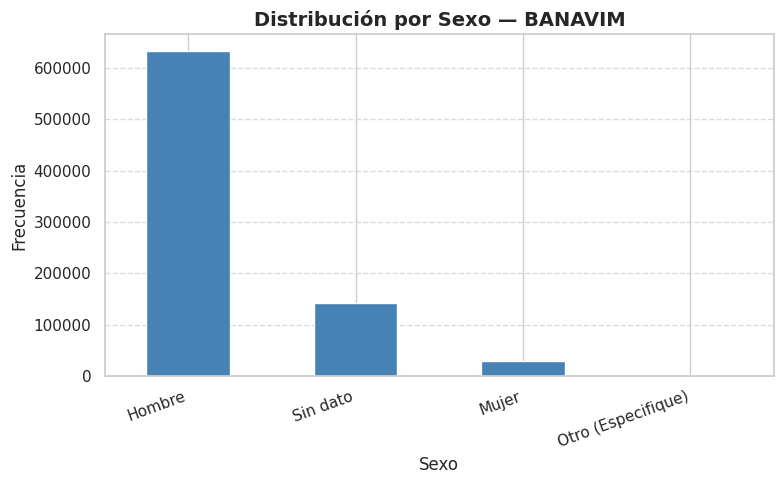

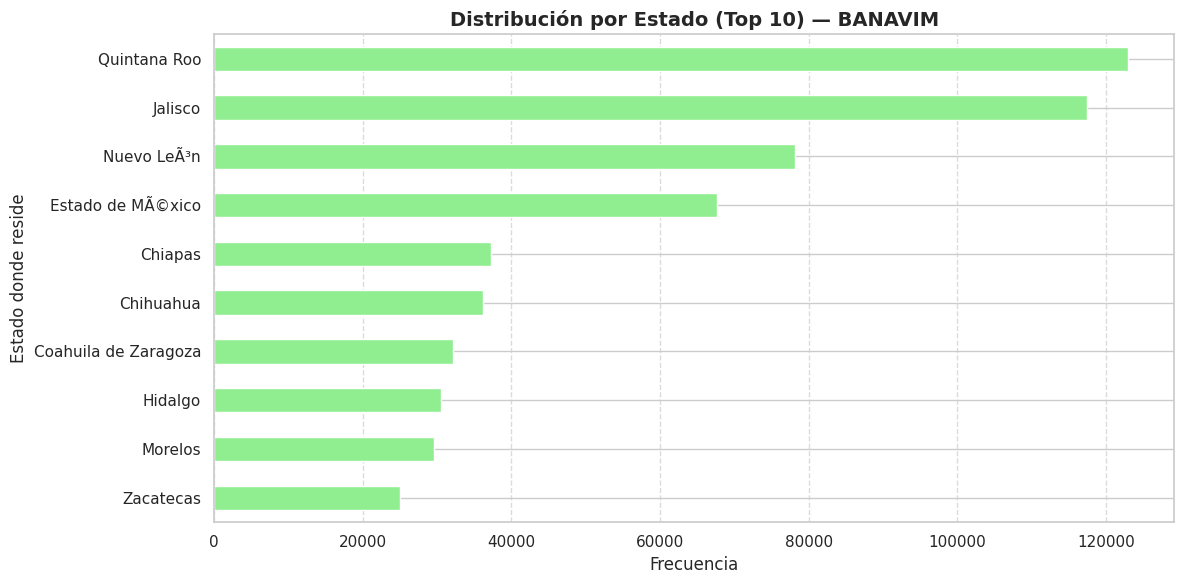

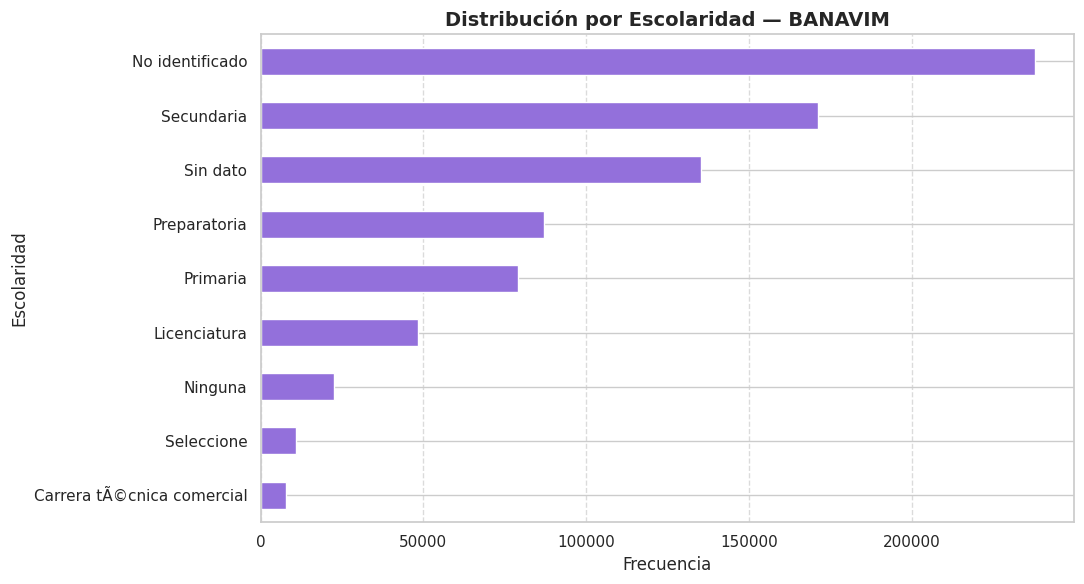

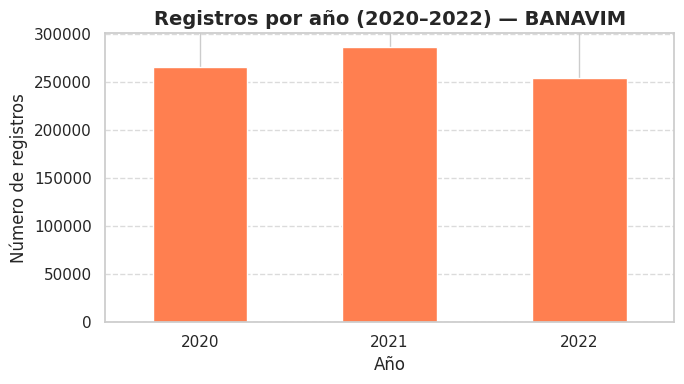

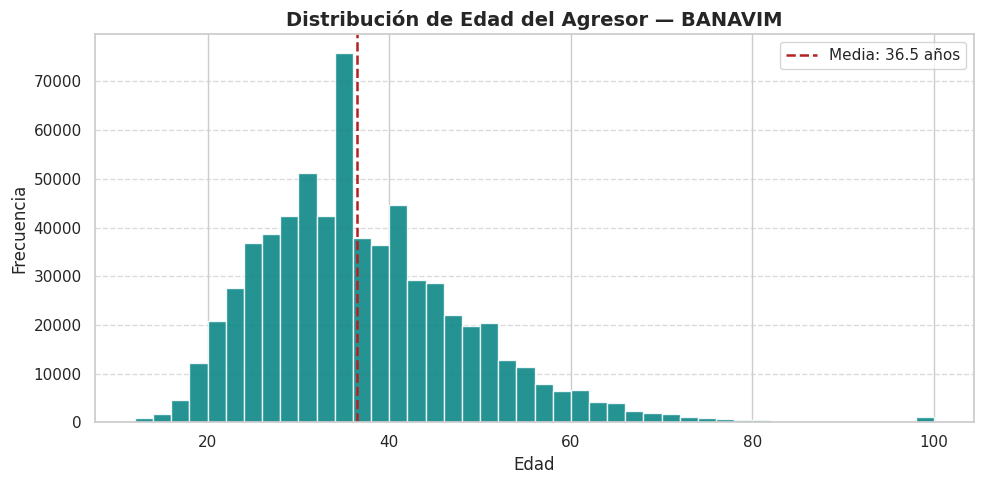

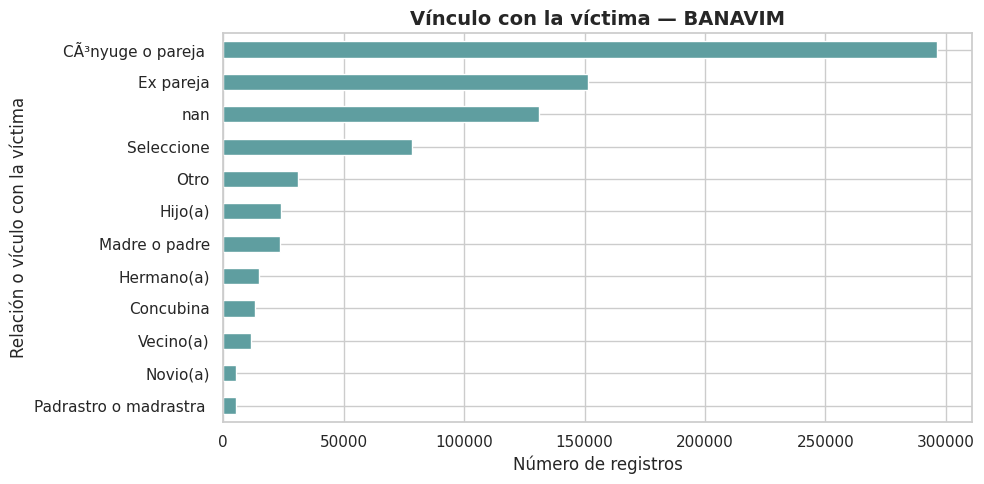

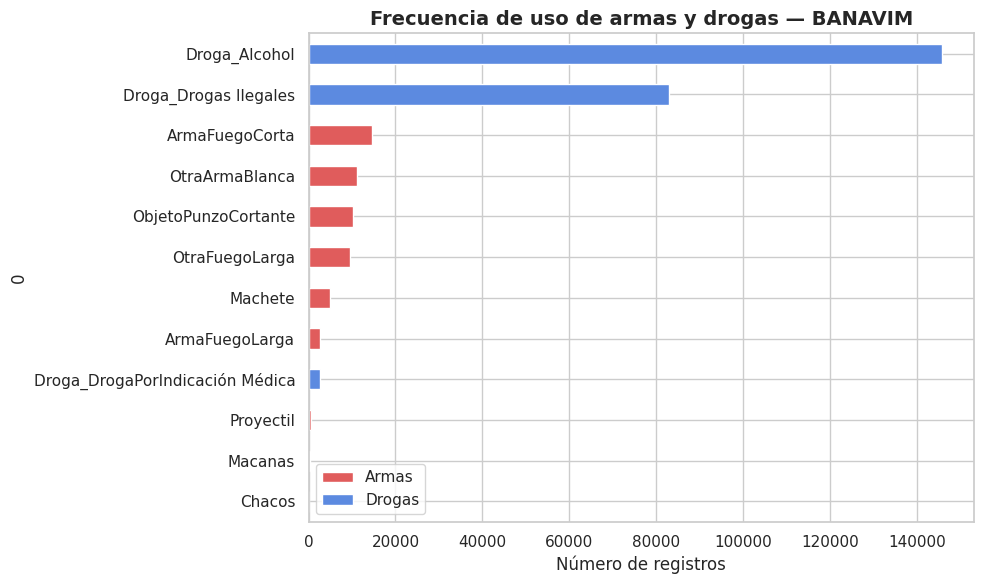

In [19]:
# 1.11 Duplicados por Identificador Único
dup_id = bv_raw[bv_raw['Identificador Único'].notna() & bv_raw['Identificador Único'].duplicated(keep=False)]
print(f'Total de registros en BANAVIM: {len(bv_raw):,}')
print(f'Registros con Identificador Único duplicado: {len(dup_id):,} ({len(dup_id)/len(bv_raw)*100:.1f}%)')
display(
    dup_id[['Identificador Único', 'Sexo', 'Estado donde reside', 'Relación o vículo con la víctima', 'año_base']]
    .sort_values('Identificador Único')
    .head(10)
)

# 1.12 Campos con formatos mixtos / mojibake
PATRON_MOJIBAKE = r'[ÃÂ�]'
cols_texto_raw = bv_raw.select_dtypes(include='object').columns.tolist()
mojibake_res = [
    {'Campo': col, 'Registros con mojibake': bv_raw[col].astype(str).str.contains(PATRON_MOJIBAKE, regex=True, na=False).sum()}
    for col in cols_texto_raw
]
mojibake_df = pd.DataFrame(mojibake_res).query('`Registros con mojibake` > 0').sort_values('Registros con mojibake', ascending=False)
print('\nCampos con problemas de codificación (mojibake):')
display(mojibake_df.reset_index(drop=True))

# 1.13 Distribuciones categóricas (texto)
print('\nCampos categóricos con posibles inconsistencias (Top 7):')
for col in ['Escolaridad', 'Estado Civil', 'Conoce al Agresor', 'Posee_algun tipo de arma']:
    print(f'\n{col}:')
    print(bv_raw[col].value_counts(dropna=False).head(7).to_string())

# Distribución: Sexo
plt.figure(figsize=(8, 5))
sc = bv_raw['Sexo'].value_counts(dropna=False)
sc.index = sc.index.fillna('Sin dato')
sc.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribución por Sexo — BANAVIM', fontsize=14, fontweight='bold')
plt.xlabel('Sexo', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Distribución: Estado (Top 10)
plt.figure(figsize=(12, 6))
bv_raw['Estado donde reside'].value_counts(dropna=False).head(10).plot(
    kind='barh', color='lightgreen', edgecolor='white')
plt.title('Distribución por Estado (Top 10) — BANAVIM', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Distribución: Escolaridad
plt.figure(figsize=(11, 6))
ec = bv_raw['Escolaridad'].value_counts(dropna=False).head(9)
ec.index = ec.index.fillna('Sin dato')
ec.sort_values().plot(kind='barh', color='mediumpurple', edgecolor='white')
plt.title('Distribución por Escolaridad — BANAVIM', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 1.14 Registros por año
plt.figure(figsize=(7, 4))
bv_raw['año_base'].value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='white')
plt.title('Registros por año (2020–2022) — BANAVIM', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de registros', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 1.15 Distribución de edad
plt.figure(figsize=(10, 5))
edad_num = pd.to_numeric(bv_raw['Edad del Agresor'], errors='coerce')
edad_valida = edad_num[(edad_num >= 12) & (edad_num <= 100)]
plt.hist(edad_valida, bins=44, color='teal', edgecolor='white', alpha=0.85)
plt.axvline(edad_valida.mean(), color='firebrick', linestyle='--', linewidth=1.8,
            label=f'Media: {edad_valida.mean():.1f} años')
plt.title('Distribución de Edad del Agresor — BANAVIM', fontsize=14, fontweight='bold')
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 1.16 Vínculo con la víctima
fig, ax = plt.subplots(figsize=(10, 5))
(
    bv_raw['Relación o vículo con la víctima']
    .value_counts(dropna=False)
    .head(12)
    .sort_values()
    .plot(kind='barh', ax=ax, color='cadetblue', edgecolor='white')
)
ax.set_title('Vínculo con la víctima — BANAVIM', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de registros', fontsize=12)
plt.tight_layout()
plt.show()

# 1.17 Uso de armas y drogas (flags binarios)
_ARMAS  = ['Chacos','Macanas','OtraArmaBlanca','ObjetoPunzoCortante',
           'Machete','Proyectil','ArmaFuegoCorta','ArmaFuegoLarga','OtraFuegoLarga']
_DROGAS = ['Droga_Alcohol','Droga_DrogaPorIndicación Médica','Droga_Drogas Ilegales']
uso = (
    bv_raw[_ARMAS + _DROGAS]
    .apply(pd.to_numeric, errors='coerce')
    .sum()
    .sort_values(ascending=True)
)
_colors = ['#5c8ae0' if c in _DROGAS else '#e05c5c' for c in uso.index]
fig, ax = plt.subplots(figsize=(10, 6))
uso.plot(kind='barh', ax=ax, color=_colors, edgecolor='white')
ax.set_title('Frecuencia de uso de armas y drogas — BANAVIM', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de registros', fontsize=12)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e05c5c', label='Armas'), Patch(facecolor='#5c8ae0', label='Drogas')], fontsize=11)
plt.tight_layout()
plt.show()

## 2. Limpieza y Normalización

### 2.1 INE

In [20]:
# 2.1 Funciones de normalización

MAPA_ESTADOS = {
    'CIUDAD DE MEXICO': 'CDMX',
    'D.F.': 'CDMX',
    'MEXICO': 'ESTADO DE MEXICO',
    'EDO MEX': 'ESTADO DE MEXICO',
    'VERACRUZ DE IGNACIO DE LA LLAVE': 'VERACRUZ',
    'MICHOACAN DE OCAMPO': 'MICHOACAN',
    'COAHUILA DE ZARAGOZA': 'COAHUILA'
}

def normalizar_nombre(texto):
    if pd.isna(texto) or not str(texto).strip():
        return None
    t = unidecode(str(texto)).lower()
    t = re.sub(r'[^a-z\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t if t else None

def nombre_canonico(texto):
    norm = normalizar_nombre(texto)
    if norm is None:
        return None
    return ' '.join(sorted(norm.split()))

def normalizar_estado(estado):
    if pd.isna(estado) or not str(estado).strip():
        return None
    e = unidecode(str(estado)).upper().strip()
    return MAPA_ESTADOS.get(e, e)

def parsear_fecha(valor):
    if pd.isna(valor) or str(valor).strip().lower() == 'indeterminada':
        return pd.NaT
    for fmt in ('%d/%m/%Y', '%Y-%m-%dT%H:%M:%S'):
        try:
            return pd.to_datetime(str(valor), format=fmt)
        except ValueError:
            pass
    return pd.to_datetime(valor, errors='coerce', dayfirst=True)

def extraer_xml_lista(texto):
    if pd.isna(texto) or not str(texto).strip():
        return None
    elementos = re.findall(r'<element>([^<]+)</element>', str(texto))
    if not elementos:
        return None
    return ' | '.join(e.strip() for e in elementos)

print('Funciones de normalización definidas')

Funciones de normalización definidas


In [21]:
# 2.2 Aplicar limpieza al INE
ine = df_ine_raw.copy()
ine.columns = ine.columns.str.strip()

ine['nombre']             = ine['Nombre'].apply(normalizar_nombre)
ine['entidad']            = ine['Entidad Federativa'].apply(normalizar_estado)
ine['fecha_resolucion']   = ine['Fecha De La Resolución'].apply(parsear_fecha)
ine['permanencia_fecha']  = ine['Permanencia'].apply(parsear_fecha)
ine['tipo_violencia']     = ine['Tipo de violencia'].apply(extraer_xml_lista)
ine['medidas_reparacion'] = ine['Medidas de reparacion'].apply(extraer_xml_lista)

print(f'INE limpio: {ine.shape}')
ine[['nombre', 'entidad', 'fecha_resolucion',
     'permanencia_fecha', 'medidas_reparacion', 'tipo_violencia']].tail(5)

INE limpio: (530, 31)


,nombre,entidad,fecha_resolucion,permanencia_fecha,medidas_reparacion,tipo_violencia
525,yolanda adelaida santos montano,OAXACA,2021-06-11,2027-09-29,Medidas de no repetición | Disculpa pública | Medida de rehabilitación | Medidas de satisfacción...,No lo precisa
526,yolanda adelaida santos montano,OAXACA,2021-06-11,2027-09-29,Medidas de no repetición | Disculpa pública | Medidas de rehabilitación | Medidas de satisfacción,No lo precisa
527,yolanda adelaida santos montano,OAXACA,2022-05-04,2028-05-05,No impone,No lo precisa
528,yoshio cesar ramirez castillo,OAXACA,2024-09-20,2029-06-04,Disculpa pública | Medidas de no repetición | Medidas de no rehabilitación,Verbal | Psicológica | Simbólica
529,yuridia pineda ordaz,OAXACA,2023-02-08,2029-06-01,Disculpa pública | Medidas de no repetición | Medidas de rehabilitación | Medidas de satisfacción,Psicológica | Simbólica


In [22]:
# 2.3 Filtrar registros 2020-2022
ine = ine[ine['fecha_resolucion'].dt.year.between(2020, 2022)].reset_index(drop=True)
print(f'INE (2020-2022): {ine.shape}')

INE (2020-2022): (162, 31)


### 2.2 BANAVIM

In [23]:
# 2.4 Limpieza BANAVIM — hoja AGRESORES (2020-2022)
FLAGS_ARMAS  = ['Chacos','Macanas','OtraArmaBlanca','ObjetoPunzoCortante',
                'Machete','Proyectil','ArmaFuegoCorta','ArmaFuegoLarga','OtraFuegoLarga']
FLAGS_DROGAS = ['Droga_Alcohol','Droga_DrogaPorIndicación Médica','Droga_Drogas Ilegales']

def limpiar_bv_agresores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['estado']          = df['Estado donde reside'].apply(normalizar_estado)
    df['municipio']       = df['Municipio donde reside'].astype(str).str.strip().replace({'nan': None})
    df['sexo']            = df['Sexo'].astype(str).str.strip().str.title().replace({'Nan': None, 'nan': None})
    df['edad']            = pd.to_numeric(df['Edad del Agresor'], errors='coerce')
    df['escolaridad']     = df['Escolaridad'].astype(str).str.strip().replace({'nan': None})
    df['estado_civil']    = df['Estado Civil'].astype(str).str.strip().replace({'nan': None})
    df['vinculo_victima'] = df['Relación o vículo con la víctima'].astype(str).str.strip().replace({'nan': None})
    df['fecha_registro']  = pd.to_datetime(df['Fecha de registro'], errors='coerce')
    for col in FLAGS_DROGAS + FLAGS_ARMAS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

bv_2020 = limpiar_bv_agresores(bv_2020)
bv_2021 = limpiar_bv_agresores(bv_2021)
bv_2022 = limpiar_bv_agresores(bv_2022)
bv = pd.concat([bv_2020, bv_2021, bv_2022], ignore_index=True)

print(f'BANAVIM 2020 limpio: {bv_2020.shape}')
print(f'BANAVIM 2021 limpio: {bv_2021.shape}')
print(f'BANAVIM 2022 limpio: {bv_2022.shape}')
print(f'BANAVIM total (bv) : {bv.shape}')
print()
campos_clave = ['estado','municipio','sexo','edad','escolaridad','estado_civil','vinculo_victima']
print('Completitud de campos clave:')
print((1 - bv[campos_clave].isnull().mean()).mul(100).round(1).to_string())

BANAVIM 2020 limpio: (265760, 36)
BANAVIM 2021 limpio: (285984, 36)
BANAVIM 2022 limpio: (254348, 36)
BANAVIM total (bv) : (806092, 36)

Completitud de campos clave:
0
estado             100.0
municipio          100.0
sexo                82.4
edad                82.1
escolaridad         83.2
estado_civil        49.9
vinculo_victima     83.8


In [24]:
# 2.5 Auditoría de codificación rota en BANAVIM
PATRON_MOJIBAKE = r'[ÃÂ�]'
cols_texto_bv = bv.select_dtypes(include='object').columns.tolist()

reporte_mojibake = []
for col in cols_texto_bv:
    serie = bv[col].astype(str)
    mask  = serie.str.contains(PATRON_MOJIBAKE, regex=True, na=False)
    reporte_mojibake.append({
        'columna': col,
        'filas_afectadas': int(mask.sum()),
        'pct_afectado': round(mask.mean() * 100, 4),
        'valores_unicos_afectados': bv.loc[mask, col].nunique(dropna=True)
    })

reporte_mojibake = (
    pd.DataFrame(reporte_mojibake)
    .sort_values('filas_afectadas', ascending=False)
    .reset_index(drop=True)
)
display(reporte_mojibake)

,columna,filas_afectadas,pct_afectado,valores_unicos_afectados
0,Relación o vículo con la víctima,305694,37.9230,6
1,vinculo_victima,305694,37.9230,6
2,municipio,296001,36.7205,646
3,Municipio donde reside,296001,36.7205,646
4,Estado donde reside,213569,26.4944,7
5,Estado Civil,61713,7.6558,1
6,estado_civil,61713,7.6558,1
7,escolaridad,10943,1.3575,3
8,Escolaridad,10943,1.3575,3
9,Cual Droga,1634,0.2027,1


In [25]:
# 2.6 Ejemplos de valores con codificación rota
ejemplos_mojibake = []
for col in cols_texto_bv:
    mask = bv[col].astype(str).str.contains(PATRON_MOJIBAKE, regex=True, na=False)
    if mask.any():
        vals = bv.loc[mask, col].dropna().astype(str).drop_duplicates().head(5)
        for v in vals:
            ejemplos_mojibake.append({'columna': col, 'valor_afectado': v})
display(pd.DataFrame(ejemplos_mojibake))

,columna,valor_afectado
0,Escolaridad,Carrera tÃ©cnica comercial
1,Escolaridad,MaestrÃ­a
2,Escolaridad,Estudios que no requieren validÃ©z oficial
3,Estado Civil,UniÃ³n libre
4,Estado donde reside,San Luis PotosÃ­
5,Estado donde reside,Ciudad de MÃ©xico
6,Estado donde reside,Estado de MÃ©xico
7,Estado donde reside,Nuevo LeÃ³n
8,Estado donde reside,QuerÃ©taro
9,Municipio donde reside,CosÃ­o


In [26]:
from ftfy import fix_text

# 2.7 Función para reparar codificación (mojibake → texto correcto)
def reparar_codificacion(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == '':
        return np.nan
    return fix_text(s)

In [27]:
# 2.8 Crear copia de BANAVIM con texto reparado
bv_fix = bv.copy()
for col in cols_texto_bv:
    bv_fix[col] = bv_fix[col].apply(reparar_codificacion)

bv_fix.to_pickle(DATA_DIR / 'banavim_fix_2020_2022.pkl')

print(f'bv original : {bv.shape}')
print(f'bv_fix      : {bv_fix.shape}')

bv original : (806092, 36)
bv_fix      : (806092, 36)


In [28]:
# 2.9 Verificación antes/después de reparación
comparacion_codificacion = []
for col in cols_texto_bv:
    antes   = bv[col].astype(str)
    despues = bv_fix[col].astype(str)
    mask_antes   = antes.str.contains(PATRON_MOJIBAKE, regex=True, na=False)
    mask_despues = despues.str.contains(PATRON_MOJIBAKE, regex=True, na=False)
    comparacion_codificacion.append({
        'columna': col,
        'filas_mojibake_antes':  int(mask_antes.sum()),
        'filas_mojibake_despues': int(mask_despues.sum()),
        'valores_modificados': int((antes != despues).sum()),
        'unicos_antes':  bv[col].nunique(dropna=True),
        'unicos_despues': bv_fix[col].nunique(dropna=True)
    })

display(
    pd.DataFrame(comparacion_codificacion)
    .sort_values('filas_mojibake_antes', ascending=False)
    .reset_index(drop=True)
)

,columna,filas_mojibake_antes,filas_mojibake_despues,valores_modificados,unicos_antes,unicos_despues
0,Relación o vículo con la víctima,305694,0,310966,23,23
1,vinculo_victima,305694,0,436621,23,23
2,municipio,296001,0,296023,1945,1945
3,Municipio donde reside,296001,0,296001,1945,1945
4,Estado donde reside,213569,0,213569,33,33
5,Estado Civil,61713,0,61713,10,10
6,estado_civil,61713,0,465786,10,10
7,escolaridad,10943,0,146315,13,13
8,Escolaridad,10943,0,10943,13,13
9,Cual Droga,1634,0,1634,3,3


In [29]:
# 2.10 Ejemplos antes/después de reparación
ejemplos_fix = []
for col in cols_texto_bv:
    tmp = pd.DataFrame({'columna': col, 'antes': bv[col], 'despues': bv_fix[col]})
    tmp = tmp[tmp['antes'].astype(str) != tmp['despues'].astype(str)].drop_duplicates()
    ejemplos_fix.append(tmp.head(5))
display(pd.concat(ejemplos_fix, ignore_index=True))

,columna,antes,despues
0,Escolaridad,Carrera tÃ©cnica comercial,Carrera técnica comercial
1,Escolaridad,MaestrÃ­a,Maestría
2,Escolaridad,Estudios que no requieren validÃ©z oficial,Estudios que no requieren validéz oficial
3,Estado Civil,UniÃ³n libre,Unión libre
4,Estado donde reside,San Luis PotosÃ­,San Luis Potosí
5,Estado donde reside,Ciudad de MÃ©xico,Ciudad de México
6,Estado donde reside,Estado de MÃ©xico,Estado de México
7,Estado donde reside,Nuevo LeÃ³n,Nuevo León
8,Estado donde reside,QuerÃ©taro,Querétaro
9,Municipio donde reside,CosÃ­o,Cosío


In [30]:
# 2.11 Guardar BANAVIM con codificación reparada
bv_fix.to_csv(
    DATA_DIR / 'banavim_fix_2020_2022.csv',
    index=False, encoding='utf-8-sig'
)
print('Guardado: banavim_fix_2020_2022.csv')

Guardado: banavim_fix_2020_2022.csv


## 3. Fusión de Datos

### 3.1 Consolidación del Golden Record INE

In [31]:
# Eliminar columnas con menos del 20% de completitud
ine = ine.drop(columns=completitud_ine[completitud_ine < 20].index)
print(f'INE ajustado (columnas >=20% completitud): {ine.shape}')

# Guardar base de incidencias
ine.to_csv(
    DATA_DIR / 'ine_incidencias_2020_2022.csv',
    index=False, encoding='utf-8-sig'
)
print('Guardado: ine_incidencias_2020_2022.csv')

INE ajustado (columnas >=20% completitud): (162, 25)
Guardado: ine_incidencias_2020_2022.csv


In [32]:
# 3.1 Campos invariantes vs. campos por incidencia
CAMPOS_INVARIANTES = [
    'Sexo', 'Ámbito Territorial', 'Entidad Federativa', 'Municipio',
    'Relación Con La Víctima', 'entidad', 'nombre',
]
CAMPOS_POR_INCIDENCIA = [
    'Número De Expediente', 'Incidencia', 'Órgano Resolutor', 'Conducta',
    'Sanción', 'Permanencia', 'Reincidencia De La Conducta', 'Resolución Penal',
    'Analizó Modo Honesto De Vivir', 'Cumple Modo Honesto De Vivir',
    'Documento Enlace', 'Enlace Utce Temporalidad', 'Modalidad de violencia',
    'fecha_resolucion', 'permanencia_fecha', 'tipo_violencia', 'medidas_reparacion',
]
print(f'Campos invariantes    : {len(CAMPOS_INVARIANTES)}')
print(f'Campos por incidencia : {len(CAMPOS_POR_INCIDENCIA)}')

Campos invariantes    : 7
Campos por incidencia : 17


In [33]:
# 3.2 Función de consolidación (golden record por persona)
def consolidar_persona(df_grupo: pd.DataFrame) -> dict:
    """
    Recibe todas las filas de un mismo Nombre y devuelve un dict con:
    - Campos invariantes : moda del valor a lo largo de las incidencias.
    - Campos por incidencia : lista ordenada cronológicamente.
    - Campos derivados : n_incidencias, es_reincidente.
    """
    df_grupo = df_grupo.sort_values('fecha_resolucion', na_position='last')
    gr = {}
    gr['Nombre'] = max(df_grupo['Nombre'].dropna().tolist(),
                       key=lambda x: len(str(x)), default=None)
    for col in CAMPOS_INVARIANTES:
        if col not in df_grupo.columns:
            gr[col] = None; continue
        vals = df_grupo[col].dropna()
        gr[col] = max(vals.mode().tolist(), key=lambda x: len(str(x))) if len(vals) > 0 else None
    for col in CAMPOS_POR_INCIDENCIA:
        if col not in df_grupo.columns:
            gr[col] = []; continue
        gr[col] = [None if pd.isna(v) else v for v in df_grupo[col].tolist()]
    gr['n_incidencias']  = len(df_grupo)
    gr['es_reincidente'] = len(df_grupo) > 1
    return gr

print('Función consolidar_persona definida')

Función consolidar_persona definida


In [34]:
# 3.3 Aplicar consolidación por Nombre
ine_con_nombre = ine[ine['Nombre'].notna()].copy()
ine_sin_nombre = ine[ine['Nombre'].isna()].copy()

registros_golden = []
for nombre, df_grupo in ine_con_nombre.groupby('Nombre', sort=False):
    registros_golden.append(consolidar_persona(df_grupo))

df_golden = pd.DataFrame(registros_golden)

print(f'Registros INE originales con nombre   : {len(ine_con_nombre):,}')
print(f'Individuos únicos tras consolidación  : {len(df_golden):,}')
print(f'Registros consolidados (reincidencias): {len(ine_con_nombre) - len(df_golden):,}')
print(f'Individuos reincidentes               : {df_golden["es_reincidente"].sum():,}')

Registros INE originales con nombre   : 162
Individuos únicos tras consolidación  : 140
Registros consolidados (reincidencias): 22
Individuos reincidentes               : 12


In [35]:
# 3.4 Vista previa de individuos reincidentes
display(
    df_golden[df_golden['es_reincidente']]
    [['Nombre', 'entidad', 'n_incidencias', 'Conducta', 'Sanción', 'fecha_resolucion']]
    .head(6)
)

,Nombre,entidad,n_incidencias,Conducta,Sanción,fecha_resolucion
25,CARLOS MARIO CORNELIO CORNELIO,TABASCO,2,[Obstaculizar la entrega de licencia para la separación del cargo de delegada municipal para par...,"[Multa económica, Multa económica]","[2022-02-28 00:00:00, 2022-03-31 00:00:00]"
28,DARWIN FÉLIX LÓPEZ,TABASCO,2,[Obstaculizar la entrega de licencia para separarse del cargo de delegada municipal para partici...,"[Multa económica, Multa económica]","[2022-02-28 00:00:00, 2022-03-31 00:00:00]"
36,ELÍ MARTÍNEZ LÓPEZ,OAXACA,2,[Conductas realizadas de manera sistemática dirigidas a sobajar a la actora de la oportunidad de...,"[Ninguna, Ninguna]","[2021-09-10 00:00:00, 2022-12-16 00:00:00]"
41,ERNESTO RUIZ FLANDES,VERACRUZ,10,[Conducta reiterada de convocar a la víctima a sesiones de cabildo sin la documentación completa...,"[Ninguna, Ninguna, Ninguna, Ninguna, Ninguna, Ninguna, Ninguna, Ninguna, Ninguna, Ninguna]","[2020-11-09 00:00:00, 2020-11-26 00:00:00, 2020-12-30 00:00:00, 2021-01-14 00:00:00, 2021-02-09 ..."
54,GILDARDO ZENTENO MORENO,CHIAPAS,2,[Reiteración y sistematización de la obstaculización e invisibilización del ejercicio del cargo ...,"[Ninguna, Ninguna]","[2021-05-01 00:00:00, 2021-11-10 00:00:00]"
57,HERMAS CORTÉS GARCÍA,VERACRUZ,2,"[Omisión de contestar diversos oficios, así como convocar a sesiones sin tomar en cuenta el esta...","[Amonestación pública, Ninguna]","[2021-03-03 00:00:00, 2021-05-12 00:00:00]"


In [36]:
# 3.5 Ejemplo detallado: persona con más incidencias
max_idx = df_golden['n_incidencias'].idxmax()
ej = df_golden.loc[max_idx]
print(f"Nombre      : {ej['Nombre']}")
print(f"Entidad     : {ej['entidad']}")
print(f"Incidencias : {ej['n_incidencias']}")
print()
for i, (cond, sanc, fecha) in enumerate(
    zip(ej['Conducta'], ej['Sanción'], ej['fecha_resolucion']), 1
):
    print(f'  [{i}] Fecha  : {fecha}')
    print(f'       Sanción : {sanc}')
    print(f'       Conducta: {str(cond)[:120]}')
    print()

Nombre      : ERNESTO RUIZ FLANDES
Entidad     : VERACRUZ
Incidencias : 10

  [1] Fecha  : 2020-11-09 00:00:00
       Sanción : Ninguna
       Conducta: Conducta reiterada de convocar a la víctima a sesiones de cabildo sin la documentación completa

  [2] Fecha  : 2020-11-26 00:00:00
       Sanción : Ninguna
       Conducta: Conducta reiterada de convocar a la víctima a sesiones de cabildo sin la documentación completa

  [3] Fecha  : 2020-12-30 00:00:00
       Sanción : Ninguna
       Conducta: Vulneración al derecho del ejercicio del cargo, al iniciar una sesión de Cabildo 15 minutos antes de la hora establecida

  [4] Fecha  : 2021-01-14 00:00:00
       Sanción : Ninguna
       Conducta: 1.-No se citó a la actora a las sesiones de cabildo con la documentación completa; 2.- Omisión de contestar peticiones d

  [5] Fecha  : 2021-02-09 00:00:00
       Sanción : Ninguna
       Conducta: Convocar a la víctima a sesiones sin la documentación correspondiente

  [6] Fecha  : 2021-04-13 00:0

### 3.2 Perfilado de candidatos para fusión

In [37]:
# Correspondencia entre columnas originales BANAVIM y columnas normalizadas
pares_banavim = [
    ('Estado donde reside',             'estado'),
    ('Municipio donde reside',           'municipio'),
    ('Sexo',                             'sexo'),
    ('Edad del Agresor',                 'edad'),
    ('Escolaridad',                      'escolaridad'),
    ('Estado Civil',                     'estado_civil'),
    ('Relación o vículo con la víctima', 'vinculo_victima'),
    ('Fecha de registro',                'fecha_registro'),
]

comparacion_pares_bv = []
for orig, der in pares_banavim:
    if orig in bv_fix.columns and der in bv_fix.columns:
        comparacion_pares_bv.append({
            'columna_original': orig, 'columna_derivada': der,
            'nulos_original': bv_fix[orig].isna().sum(),
            'nulos_derivada': bv_fix[der].isna().sum(),
            'unicos_original': bv_fix[orig].nunique(dropna=True),
            'unicos_derivada': bv_fix[der].nunique(dropna=True),
            'ejemplo_original': bv_fix[orig].dropna().astype(str).iloc[0] if bv_fix[orig].notna().any() else None,
            'ejemplo_derivada': bv_fix[der].dropna().astype(str).iloc[0] if bv_fix[der].notna().any() else None,
        })
display(pd.DataFrame(comparacion_pares_bv))

,columna_original,columna_derivada,nulos_original,nulos_derivada,unicos_original,unicos_derivada,ejemplo_original,ejemplo_derivada
0,Estado donde reside,estado,22,22,33,33,Aguascalientes,AGUASCALIENTES
1,Municipio donde reside,municipio,22,22,1945,1945,Aguascalientes,Aguascalientes
2,Sexo,sexo,141475,141475,3,3,Hombre,Hombre
3,Edad del Agresor,edad,144484,144484,97,97,34,34.0
4,Escolaridad,escolaridad,135372,135372,13,13,No identificado,No identificado
5,Estado Civil,estado_civil,404073,404073,10,10,Unión libre,Unión libre
6,Relación o vículo con la víctima,vinculo_victima,130927,130927,23,23,Ex pareja,Ex pareja
7,Fecha de registro,fecha_registro,0,0,756919,756919,2020-09-03 08:59:29,2020-09-03 08:59:29


In [38]:
# Perfilado de campos categóricos candidatos para fusión en INE
campos_ine_fusion = ['Sexo', 'entidad', 'Municipio', 'Relación Con La Víctima']
campos_ine_fusion = [c for c in campos_ine_fusion if c in ine.columns]

resumen_cat_ine = []
for col in campos_ine_fusion:
    resumen_cat_ine.append({
        'campo': col, 'registros': len(ine),
        'no_nulos': ine[col].notna().sum(), 'missing': ine[col].isna().sum(),
        'completitud_%': round(ine[col].notna().mean() * 100, 2),
        'valores_unicos': ine[col].nunique(dropna=True)
    })
resumen_cat_ine = pd.DataFrame(resumen_cat_ine)
display(resumen_cat_ine)

distincts_ine = []
for col in campos_ine_fusion:
    tmp = ine[col].value_counts(dropna=False).reset_index()
    tmp.columns = ['valor', 'frecuencia']
    tmp.insert(0, 'campo', col)
    tmp['porcentaje'] = (tmp['frecuencia'] / len(ine) * 100).round(2)
    distincts_ine.append(tmp)
distincts_ine = pd.concat(distincts_ine, ignore_index=True)
display(distincts_ine)

resumen_cat_ine.to_csv(DATA_DIR / 'resumen_categoricos_ine_fusion.csv', index=False, encoding='utf-8-sig')
distincts_ine.to_csv(DATA_DIR / 'distincts_categoricos_ine_fusion.csv', index=False, encoding='utf-8-sig')
print('Perfilado INE guardado.')

,campo,registros,no_nulos,missing,completitud_%,valores_unicos
0,Sexo,162,162,0,100.00,2
1,entidad,162,162,0,100.00,18
2,Municipio,162,129,33,79.63,59
3,Relación Con La Víctima,162,162,0,100.00,7


,campo,valor,frecuencia,porcentaje
0,Sexo,Hombre,136,83.95
1,Sexo,Mujer,26,16.05
2,entidad,OAXACA,65,40.12
3,entidad,VERACRUZ,22,13.58
4,entidad,TABASCO,19,11.73
...,...,...,...,...
82,Relación Con La Víctima,Jerárquica,33,20.37
83,Relación Con La Víctima,Subordinación,5,3.09
84,Relación Con La Víctima,Otro,3,1.85
85,Relación Con La Víctima,Opositor en la contienda,2,1.23


Perfilado INE guardado.


### 3.3 Normalización y bases para fusión

In [39]:
# 3.3 Funciones de normalización para campos de fusión

NULOS_SEMANTICOS = {
    '', 'NAN', 'NONE', 'NULL', 'NA', 'N/A',
    'SIN DATO', 'SIN DATOS',
    'NO ESPECIFICADO', 'NO ESPECIFICADA', 'NO SE ESPECIFICA',
    'SE IGNORA', 'IGNORADO', 'IGNORADA',
    'NO APLICA', 'NO APLICA.',
    'INDETERMINADO', 'INDETERMINADA'
}

def normalizar_categoria_fusion(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if s == '': return np.nan
    s = unidecode(s).upper()
    s = re.sub(r'[^A-Z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return np.nan if s in NULOS_SEMANTICOS else s

def normalizar_sexo_fusion(x):
    s = normalizar_categoria_fusion(x)
    if pd.isna(s): return np.nan
    return {'H':'H','HOMBRE':'H','MASCULINO':'H','M':'M','MUJER':'M','F':'M','FEMENINO':'M'}.get(s, s)

print('Funciones de normalización para fusión definidas')

Funciones de normalización para fusión definidas


In [40]:
# 7.2 Crear base INE orientada a fusión
ine_fusion = ine.copy()
if 'id_ine_caso' not in ine_fusion.columns:
    ine_fusion['id_ine_caso'] = 'INE_' + ine_fusion.index.astype(str).str.zfill(5)

ine_fusion['sexo']           = ine_fusion['Sexo'].apply(normalizar_sexo_fusion)
ine_fusion['estado']         = ine_fusion['entidad'].apply(normalizar_categoria_fusion)
ine_fusion['municipio']      = ine_fusion['Municipio'].apply(normalizar_categoria_fusion)
ine_fusion['vinculo_victima']= ine_fusion['Relación Con La Víctima'].apply(normalizar_categoria_fusion)
ine_fusion['anio_resolucion']= ine_fusion['fecha_resolucion'].dt.year

cols_keep = [c for c in ['id_ine_caso','Nombre','Número De Expediente',
             'fecha_resolucion','anio_resolucion','sexo','estado',
             'municipio','vinculo_victima'] if c in ine_fusion.columns]
ine_fusion = ine_fusion[cols_keep].copy()

display(ine_fusion.head())
print(f'ine_fusion: {ine_fusion.shape}')

,id_ine_caso,Nombre,Número De Expediente,fecha_resolucion,anio_resolucion,sexo,estado,municipio,vinculo_victima
0,INE_00000,AARÓN VEGA REA,SRE-PSC-41/2022,2022-04-07,2022,H,GUANAJUATO,NaN,NINGUNA
1,INE_00001,ABEL TOVILLA CARPIO,IEPC/PE/GJMA/081/2021,2021-11-10,2021,H,CHIAPAS,TEOPISCA,PARES
2,INE_00002,ADÁN FRAUSTO ARELLANO,TEE-PES-18/2021,2021-07-02,2021,H,NAYARIT,EL NAYAR,JERARQUICA
3,INE_00003,ADRIANA AVENDAÑO NIÑO,PES-58/2021,2021-06-04,2021,M,OAXACA,SAN ANDRES ZAUTLA,NINGUNA
4,INE_00004,ALBERTO ALFONSO MENDOZA CRUZ,JDCI/52/2021 y su acumulado JDCI/56/2021,2021-07-09,2021,H,OAXACA,SAN LORENZO CACAOTEPEC,JERARQUICA


ine_fusion: (162, 9)


In [41]:
# 7.3 Perfilado de campos canónicos INE para fusión
campos_ine_canon = ['sexo', 'estado', 'municipio', 'vinculo_victima']
resumen_ine_canon = []
for col in campos_ine_canon:
    resumen_ine_canon.append({
        'campo': col, 'registros': len(ine_fusion),
        'no_nulos': ine_fusion[col].notna().sum(),
        'missing': ine_fusion[col].isna().sum(),
        'completitud_%': round(ine_fusion[col].notna().mean() * 100, 2),
        'valores_unicos': ine_fusion[col].nunique(dropna=True)
    })
display(pd.DataFrame(resumen_ine_canon))

,campo,registros,no_nulos,missing,completitud_%,valores_unicos
0,sexo,162,162,0,100.00,2
1,estado,162,162,0,100.00,18
2,municipio,162,129,33,79.63,59
3,vinculo_victima,162,162,0,100.00,7


In [42]:
# bv_fusion: base BANAVIM orientada a fusión
bv_fusion = bv_fix.copy()
if 'id_bv_caso' not in bv_fusion.columns:
    bv_fusion['id_bv_caso'] = 'BV_' + bv_fusion.index.astype(str).str.zfill(7)

bv_fusion['sexo']           = bv_fusion['sexo'].apply(normalizar_sexo_fusion)
bv_fusion['estado']         = bv_fusion['estado'].apply(normalizar_categoria_fusion)
bv_fusion['municipio']      = bv_fusion['municipio'].apply(normalizar_categoria_fusion)
bv_fusion['vinculo_victima']= bv_fusion['vinculo_victima'].apply(normalizar_categoria_fusion)
bv_fusion['anio_registro']  = pd.to_datetime(bv_fusion['fecha_registro'], errors='coerce').dt.year

cols_bv = [c for c in ['id_bv_caso','Identificador Único','año_base',
           'fecha_registro','anio_registro','sexo','estado',
           'municipio','vinculo_victima'] if c in bv_fusion.columns]
bv_fusion = bv_fusion[cols_bv].copy()

display(bv_fusion.head())
print(f'bv_fusion: {bv_fusion.shape}')

,id_bv_caso,Identificador Único,año_base,fecha_registro,anio_registro,sexo,estado,municipio,vinculo_victima
0,BV_0000000,0128900022-2,2020,2020-09-03 08:59:29,2020,H,AGUASCALIENTES,AGUASCALIENTES,EX PAREJA
1,BV_0000001,0128900106-2,2020,2020-10-20 09:25:05,2020,H,AGUASCALIENTES,AGUASCALIENTES,CONYUGE O PAREJA
2,BV_0000002,0128900132-2,2020,2020-07-02 08:07:24,2020,H,AGUASCALIENTES,AGUASCALIENTES,CONYUGE O PAREJA
3,BV_0000003,0128900350-2,2020,2020-01-29 15:48:51,2020,H,AGUASCALIENTES,AGUASCALIENTES,EX PAREJA
4,BV_0000004,0128900563-2,2020,2020-12-07 13:50:38,2020,H,AGUASCALIENTES,COSIO,CONYUGE O PAREJA


bv_fusion: (806092, 9)


In [43]:
# Perfilado de campos canónicos BANAVIM para fusión
resumen_bv_fusion = []
for col in ['sexo', 'estado', 'municipio', 'vinculo_victima']:
    resumen_bv_fusion.append({
        'campo': col, 'registros': len(bv_fusion),
        'no_nulos': bv_fusion[col].notna().sum(),
        'missing': bv_fusion[col].isna().sum(),
        'completitud_%': round(bv_fusion[col].notna().mean() * 100, 2),
        'valores_unicos': bv_fusion[col].nunique(dropna=True)
    })
display(pd.DataFrame(resumen_bv_fusion))

,campo,registros,no_nulos,missing,completitud_%,valores_unicos
0,sexo,806092,664617,141475,82.45,3
1,estado,806092,806070,22,100.00,33
2,municipio,806092,806070,22,100.00,1945
3,vinculo_victima,806092,675165,130927,83.76,23


In [44]:
# Distribución de vínculo en BANAVIM y comparación con INE
distincts_vinculo_bv = bv_fusion['vinculo_victima'].value_counts(dropna=False).reset_index()
distincts_vinculo_bv.columns = ['vinculo_victima', 'frecuencia']
distincts_vinculo_bv['porcentaje'] = (distincts_vinculo_bv['frecuencia'] / len(bv_fusion) * 100).round(2)
display(distincts_vinculo_bv)

vinculos_ine = ine_fusion['vinculo_victima'].value_counts(dropna=False).reset_index()
vinculos_ine.columns = ['valor', 'frecuencia_ine']
vinculos_ine['porcentaje_ine'] = (vinculos_ine['frecuencia_ine'] / len(ine_fusion) * 100).round(2)

vinculos_bv = bv_fusion['vinculo_victima'].value_counts(dropna=False).reset_index()
vinculos_bv.columns = ['valor', 'frecuencia_banavim']
vinculos_bv['porcentaje_banavim'] = (vinculos_bv['frecuencia_banavim'] / len(bv_fusion) * 100).round(2)

comparacion_vinculos = vinculos_ine.merge(vinculos_bv, on='valor', how='outer', indicator=True)
comparacion_vinculos['aparece_en'] = comparacion_vinculos['_merge'].map(
    {'left_only': 'solo INE', 'right_only': 'solo BANAVIM', 'both': 'ambas'})
cols_num = ['frecuencia_ine','porcentaje_ine','frecuencia_banavim','porcentaje_banavim']
comparacion_vinculos[cols_num] = comparacion_vinculos[cols_num].fillna(0)
display(comparacion_vinculos.drop(columns='_merge')
        .sort_values(['aparece_en','frecuencia_banavim'], ascending=[True,False]))

,vinculo_victima,frecuencia,porcentaje
0,CONYUGE O PAREJA,296188,36.74
1,EX PAREJA,151341,18.77
2,NaN,130927,16.24
3,SELECCIONE,78554,9.75
4,OTRO,31138,3.86
5,HIJO A,23839,2.96
6,MADRE O PADRE,23766,2.95
7,HERMANO A,15065,1.87
8,CONCUBINA,13298,1.65
9,VECINO A,11678,1.45


,valor,frecuencia_ine,porcentaje_ine,frecuencia_banavim,porcentaje_banavim,aparece_en
9,JERARQUICA,33.0,20.37,0.0,0.00,solo INE
12,NINGUNA,57.0,35.19,0.0,0.00,solo INE
14,OPOSITOR EN LA CONTIENDA,2.0,1.23,0.0,0.00,solo INE
15,OTRA,1.0,0.62,0.0,0.00,solo INE
19,PARES,61.0,37.65,0.0,0.00,solo INE
25,SUBORDINACION,5.0,3.09,0.0,0.00,solo INE
3,CONYUGE O PAREJA,0.0,0.00,296188.0,36.74,solo BANAVIM
5,EX PAREJA,0.0,0.00,151341.0,18.77,solo BANAVIM
29,NaN,0.0,0.00,130927.0,16.24,solo BANAVIM
22,SELECCIONE,0.0,0.00,78554.0,9.75,solo BANAVIM


### 3.4 Homologación semántica del vínculo con la víctima

In [45]:
# 3.4 Mapas semánticos de vínculo con la víctima
NULOS_SEMANTICOS.update({
    'SELECCIONE', 'SELECCIONA', 'SELECCIONAR',
    'SIN ESPECIFICAR', 'SIN DATO', 'SIN DATOS',
    'NO ESPECIFICADO', 'NO ESPECIFICADA', 'NO SE ESPECIFICA'
})

MAPA_VINCULO_INE = {
    'PARES': 'PARES',
    'JERARQUICA': 'JERARQUICA_SUBORDINACION',
    'SUBORDINACION': 'JERARQUICA_SUBORDINACION',
    'OPOSITOR EN LA CONTIENDA': 'INSTITUCIONAL_POLITICA',
    'OTRO': 'OTRO', 'OTRA': 'OTRO', 'OTRA RELACION': 'OTRO',
    'NINGUNA': 'NINGUNA',
}

MAPA_VINCULO_BANAVIM = {
    'COMPANERO A': 'PARES', 'COMPANERO': 'PARES', 'COMPANERA': 'PARES',
    'COMPANERO DE TRABAJO': 'PARES', 'COMPANERA DE TRABAJO': 'PARES',
    'JEFE A': 'JERARQUICA_SUBORDINACION', 'JEFE': 'JERARQUICA_SUBORDINACION',
    'JEFA': 'JERARQUICA_SUBORDINACION', 'PATRON A': 'JERARQUICA_SUBORDINACION',
    'PATRON': 'JERARQUICA_SUBORDINACION', 'PATRONA': 'JERARQUICA_SUBORDINACION',
    'SUPERIOR': 'JERARQUICA_SUBORDINACION', 'SUPERIOR JERARQUICO': 'JERARQUICA_SUBORDINACION',
    'DIRECTOR A': 'JERARQUICA_SUBORDINACION', 'DIRECTOR': 'JERARQUICA_SUBORDINACION',
    'JEFE A O PATRON A': 'JERARQUICA_SUBORDINACION',
    'SERVIDOR PUBLICO': 'INSTITUCIONAL_POLITICA', 'SERVIDORA PUBLICA': 'INSTITUCIONAL_POLITICA',
    'FUNCIONARIO PUBLICO': 'INSTITUCIONAL_POLITICA', 'AUTORIDAD PUBLICA': 'INSTITUCIONAL_POLITICA',
    'AUTORIDAD': 'INSTITUCIONAL_POLITICA',
    'OTRO': 'OTRO', 'OTRA': 'OTRO', 'OTRA RELACION': 'OTRO', 'OTRO TIPO DE RELACION': 'OTRO',
    'CONYUGE O PAREJA': 'PAREJA_EXPAREJA', 'CONYUGE': 'PAREJA_EXPAREJA', 'PAREJA': 'PAREJA_EXPAREJA',
    'ESPOSO': 'PAREJA_EXPAREJA', 'ESPOSA': 'PAREJA_EXPAREJA',
    'EX PAREJA': 'PAREJA_EXPAREJA', 'EXPAREJA': 'PAREJA_EXPAREJA',
    'EX CONYUGE': 'PAREJA_EXPAREJA', 'NOVIO A': 'PAREJA_EXPAREJA',
    'NOVIO': 'PAREJA_EXPAREJA', 'NOVIA': 'PAREJA_EXPAREJA',
    'EX NOVIO A': 'PAREJA_EXPAREJA', 'EX NOVIO': 'PAREJA_EXPAREJA',
    'HIJO A': 'FAMILIAR', 'HIJO': 'FAMILIAR', 'HIJA': 'FAMILIAR',
    'MADRE O PADRE': 'FAMILIAR', 'MADRE': 'FAMILIAR', 'PADRE': 'FAMILIAR',
    'HERMANO A': 'FAMILIAR', 'HERMANO': 'FAMILIAR', 'HERMANA': 'FAMILIAR',
    'ABUELO A': 'FAMILIAR', 'TIO A': 'FAMILIAR', 'TIO': 'FAMILIAR', 'TIA': 'FAMILIAR',
    'PRIMO A': 'FAMILIAR', 'PRIMO': 'FAMILIAR', 'PRIMA': 'FAMILIAR', 'FAMILIAR': 'FAMILIAR',
    'VECINO A': 'COMUNITARIO_SOCIAL', 'VECINO': 'COMUNITARIO_SOCIAL', 'VECINA': 'COMUNITARIO_SOCIAL',
    'CONOCIDO A': 'COMUNITARIO_SOCIAL', 'CONOCIDO': 'COMUNITARIO_SOCIAL',
    'AMIGO A': 'COMUNITARIO_SOCIAL', 'AMIGO': 'COMUNITARIO_SOCIAL', 'AMIGA': 'COMUNITARIO_SOCIAL',
    'DESCONOCIDO A': 'COMUNITARIO_SOCIAL', 'DESCONOCIDO': 'COMUNITARIO_SOCIAL',
    'PROFESOR A': 'COMUNITARIO_SOCIAL', 'MAESTRO A': 'COMUNITARIO_SOCIAL',
    'TUTOR A': 'COMUNITARIO_SOCIAL', 'CUIDADOR A': 'COMUNITARIO_SOCIAL',
}

In [46]:
def homologar_vinculo(x, mapa):
    """
    Asigna una categoría semántica común al vínculo con la víctima.
    Devuelve MISSING si el valor es nulo/placeholder, REVISAR si no está en el mapa.
    """
    s = normalizar_categoria_fusion(x)
    if pd.isna(s): return 'MISSING'
    if s in NULOS_SEMANTICOS: return 'MISSING'
    return mapa.get(s, 'REVISAR')

In [47]:
# Aplicar homologación a INE y BANAVIM
ine_fusion['vinculo_grupo'] = ine_fusion['vinculo_victima'].apply(
    lambda x: homologar_vinculo(x, MAPA_VINCULO_INE))
bv_fusion['vinculo_grupo']  = bv_fusion['vinculo_victima'].apply(
    lambda x: homologar_vinculo(x, MAPA_VINCULO_BANAVIM))

In [48]:
# Conteos de categorías homologadas
def conteo_grupos_vinculo(df, nombre_base):
    conteo = df['vinculo_grupo'].value_counts(dropna=False).reset_index()
    conteo.columns = ['vinculo_grupo', 'frecuencia']
    conteo['porcentaje'] = (conteo['frecuencia'] / len(df) * 100).round(2)
    conteo.insert(0, 'base', nombre_base)
    return conteo

conteo_vinculo_ine = conteo_grupos_vinculo(ine_fusion, 'INE')
conteo_vinculo_bv  = conteo_grupos_vinculo(bv_fusion, 'BANAVIM')
conteo_vinculos    = pd.concat([conteo_vinculo_ine, conteo_vinculo_bv], ignore_index=True)
display(conteo_vinculos)

,base,vinculo_grupo,frecuencia,porcentaje
0,INE,PARES,61,37.65
1,INE,NINGUNA,57,35.19
2,INE,JERARQUICA_SUBORDINACION,38,23.46
3,INE,OTRO,4,2.47
4,INE,INSTITUCIONAL_POLITICA,2,1.23
5,BANAVIM,PAREJA_EXPAREJA,452936,56.19
6,BANAVIM,MISSING,209481,25.99
7,BANAVIM,FAMILIAR,71860,8.91
8,BANAVIM,OTRO,31139,3.86
9,BANAVIM,REVISAR,24084,2.99


In [49]:
# Comparación de grupos homologados entre INE y BANAVIM
comparacion_grupos_vinculo = conteo_vinculo_ine.merge(
    conteo_vinculo_bv, on='vinculo_grupo', how='outer', suffixes=('_ine', '_banavim'))
cols_num = ['frecuencia_ine','porcentaje_ine','frecuencia_banavim','porcentaje_banavim']
comparacion_grupos_vinculo[cols_num] = comparacion_grupos_vinculo[cols_num].fillna(0)
display(comparacion_grupos_vinculo[['vinculo_grupo'] + cols_num].sort_values('vinculo_grupo'))

,vinculo_grupo,frecuencia_ine,porcentaje_ine,frecuencia_banavim,porcentaje_banavim
0,COMUNITARIO_SOCIAL,0.0,0.00,12235.0,1.52
1,FAMILIAR,0.0,0.00,71860.0,8.91
2,INSTITUCIONAL_POLITICA,2.0,1.23,515.0,0.06
3,JERARQUICA_SUBORDINACION,38.0,23.46,1927.0,0.24
4,MISSING,0.0,0.00,209481.0,25.99
5,NINGUNA,57.0,35.19,0.0,0.00
6,OTRO,4.0,2.47,31139.0,3.86
7,PAREJA_EXPAREJA,0.0,0.00,452936.0,56.19
8,PARES,61.0,37.65,1915.0,0.24
9,REVISAR,0.0,0.00,24084.0,2.99


In [50]:
# Valores que quedaron en REVISAR
for base_name, df_base in [('INE', ine_fusion), ('BANAVIM', bv_fusion)]:
    print(f'{base_name} — valores en REVISAR')
    revisar = (
        df_base.loc[df_base['vinculo_grupo'].eq('REVISAR'), 'vinculo_victima']
        .value_counts(dropna=False).reset_index()
    )
    revisar.columns = ['valor', 'frecuencia']
    display(revisar)
    print(f'{base_name} — valores en MISSING')
    missing = (
        df_base.loc[df_base['vinculo_grupo'].eq('MISSING'), 'vinculo_victima']
        .value_counts(dropna=False).reset_index()
    )
    missing.columns = ['valor', 'frecuencia']
    display(missing)

INE — valores en REVISAR


,valor,frecuencia


INE — valores en MISSING


,valor,frecuencia


BANAVIM — valores en REVISAR


,valor,frecuencia
0,CONCUBINA,13298
1,PADRASTRO O MADRASTRA,5272
2,SOBRINO A,2468
3,SUEGRO A,1765
4,NIETO A,1281


BANAVIM — valores en MISSING


,valor,frecuencia
0,NaN,130927
1,SELECCIONE,78554


In [51]:
# Ajustes al mapa BANAVIM tras revisar valores en REVISAR
MAPA_VINCULO_BANAVIM.update({
    'CONCUBINA': 'PAREJA_EXPAREJA', 'CONCUBINO': 'PAREJA_EXPAREJA',
    'PADRASTRO O MADRASTRA': 'FAMILIAR', 'PADRASTRO': 'FAMILIAR', 'MADRASTRA': 'FAMILIAR',
    'SOBRINO A': 'FAMILIAR', 'SOBRINO': 'FAMILIAR', 'SOBRINA': 'FAMILIAR',
    'SUEGRO A': 'FAMILIAR', 'SUEGRA': 'FAMILIAR',
    'NIETO A': 'FAMILIAR', 'NIETO': 'FAMILIAR', 'NIETA': 'FAMILIAR',
})

In [52]:
# Recalcular homologación con el mapa actualizado
ine_fusion['vinculo_grupo'] = ine_fusion['vinculo_victima'].apply(
    lambda x: homologar_vinculo(x, MAPA_VINCULO_INE))
bv_fusion['vinculo_grupo']  = bv_fusion['vinculo_victima'].apply(
    lambda x: homologar_vinculo(x, MAPA_VINCULO_BANAVIM))

for base_name, df_base in [('INE', ine_fusion), ('BANAVIM', bv_fusion)]:
    revisar_n = df_base['vinculo_grupo'].eq('REVISAR').sum()
    print(f'{base_name} — valores aún en REVISAR: {revisar_n}')

INE — valores aún en REVISAR: 0
BANAVIM — valores aún en REVISAR: 0


In [53]:
# Comparación de vocabularios entre INE y BANAVIM
campos_comparables = ['sexo', 'estado', 'municipio', 'vinculo_grupo']
comparacion_vocabularios = []
for col in campos_comparables:
    vals_ine = set(ine_fusion[col].dropna().unique())
    vals_bv  = set(bv_fusion[col].dropna().unique())
    inter    = vals_ine & vals_bv
    comparacion_vocabularios.append({
        'campo': col,
        'unicos_ine': len(vals_ine), 'unicos_banavim': len(vals_bv),
        'coincidentes': len(inter),
        'solo_ine': len(vals_ine - vals_bv), 'solo_banavim': len(vals_bv - vals_ine),
        'pct_ine_cubierto': round(len(inter)/len(vals_ine)*100, 2) if vals_ine else np.nan,
        'pct_banavim_cubierto': round(len(inter)/len(vals_bv)*100, 2) if vals_bv else np.nan,
    })
comparacion_vocabularios = pd.DataFrame(comparacion_vocabularios)
display(comparacion_vocabularios)

,campo,unicos_ine,unicos_banavim,coincidentes,solo_ine,solo_banavim,pct_ine_cubierto,pct_banavim_cubierto
0,sexo,2,3,2,0,1,100.00,66.67
1,estado,18,33,14,4,19,77.78,42.42
2,municipio,59,1945,52,7,1893,88.14,2.67
3,vinculo_grupo,5,8,4,1,4,80.00,50.00


In [54]:
# Revisar valores de sexo y estado antes del ajuste final
for base_name, df_base in [('INE', ine_fusion), ('BANAVIM', bv_fusion)]:
    print(f'\n{base_name} — sexo')
    s = df_base['sexo'].value_counts(dropna=False).reset_index()
    s.columns = ['sexo', 'frecuencia']
    s['porcentaje'] = (s['frecuencia'] / len(df_base) * 100).round(2)
    display(s)
    print(f'{base_name} — estado (top 10)')
    e = df_base['estado'].value_counts(dropna=False).head(10).reset_index()
    e.columns = ['estado', 'frecuencia']
    display(e)


INE — sexo


,sexo,frecuencia,porcentaje
0,H,136,83.95
1,M,26,16.05


INE — estado (top 10)


,estado,frecuencia
0,OAXACA,65
1,VERACRUZ,22
2,TABASCO,19
3,CHIAPAS,8
4,BAJA CALIFORNIA SUR,7
5,MORELOS,6
6,NAYARIT,6
7,SAN LUIS POTOSI,5
8,PUEBLA,5
9,GUANAJUATO,4



BANAVIM — sexo


,sexo,frecuencia,porcentaje
0,H,634075,78.66
1,NaN,141475,17.55
2,M,29651,3.68
3,OTRO ESPECIFIQUE,891,0.11


BANAVIM — estado (top 10)


,estado,frecuencia
0,QUINTANA ROO,123036
1,JALISCO,117431
2,NUEVO LEA3N,78193
3,ESTADO DE MA C XICO,67640
4,CHIAPAS,37279
5,CHIHUAHUA,36200
6,COAHUILA,32161
7,HIDALGO,30498
8,MORELOS,29564
9,ZACATECAS,25015


In [55]:
# Ajuste final de sexo y estado para bases de fusión
VALORES_MISSING_FUSION = {
    '', 'NAN', 'NONE', 'NULL', 'NA', 'N/A',
    'SELECCIONE', 'SELECCIONA', 'SELECCIONAR',
    'SIN DATO', 'SIN DATOS', 'NO ESPECIFICADO', 'NO ESPECIFICADA',
    'NO SE ESPECIFICA', 'OTRO ESPECIFIQUE'
}

def limpiar_sexo_final(x):
    s = normalizar_categoria_fusion(x)
    if pd.isna(s) or s in VALORES_MISSING_FUSION: return np.nan
    return {'H':'H','HOMBRE':'H','MASCULINO':'H','M':'M','MUJER':'M','F':'M','FEMENINO':'M'}.get(s, s)

MAPA_ESTADO_FINAL = {
    'NUEVO LEA3N': 'NUEVO LEON', 'ESTADO DE MA C XICO': 'MEXICO',
    'YUCATA N': 'YUCATAN', 'MICHOACA N DE OCAMPO': 'MICHOACAN',
    'SAN LUIS POTOSA': 'SAN LUIS POTOSI', 'QUERA C TARO': 'QUERETARO',
    'CIUDAD DE MA C XICO': 'CDMX', 'CIUDAD DE MEXICO': 'CDMX',
    'DISTRITO FEDERAL': 'CDMX', 'VERACRUZ IGNACIO DE LA LLAVE': 'VERACRUZ',
    'MICHOACAN DE OCAMPO': 'MICHOACAN', 'COAHUILA DE ZARAGOZA': 'COAHUILA',
    'MEXICO': 'MEXICO', 'ESTADO DE MEXICO': 'MEXICO'
}

def limpiar_estado_final(x):
    s = normalizar_categoria_fusion(x)
    if pd.isna(s) or s in VALORES_MISSING_FUSION: return np.nan
    return MAPA_ESTADO_FINAL.get(s, s)

ine_fusion['sexo']   = ine_fusion['sexo'].apply(limpiar_sexo_final)
bv_fusion['sexo']    = bv_fusion['sexo'].apply(limpiar_sexo_final)
ine_fusion['estado'] = ine_fusion['estado'].apply(limpiar_estado_final)
bv_fusion['estado']  = bv_fusion['estado'].apply(limpiar_estado_final)
print('Ajuste de sexo y estado aplicado.')

Ajuste de sexo y estado aplicado.


In [56]:
# Verificar sexo y estado después del ajuste
for base_name, df_base in [('INE', ine_fusion), ('BANAVIM', bv_fusion)]:
    print(f'\n{base_name} — sexo (post-ajuste)')
    s = df_base['sexo'].value_counts(dropna=False).reset_index()
    s.columns = ['sexo', 'frecuencia']
    s['porcentaje'] = (s['frecuencia'] / len(df_base) * 100).round(2)
    display(s)
    print(f'{base_name} — estado (post-ajuste, top 10)')
    e = df_base['estado'].value_counts(dropna=False).head(10).reset_index()
    e.columns = ['estado', 'frecuencia']
    display(e)


INE — sexo (post-ajuste)


,sexo,frecuencia,porcentaje
0,H,136,83.95
1,M,26,16.05


INE — estado (post-ajuste, top 10)


,estado,frecuencia
0,OAXACA,65
1,VERACRUZ,22
2,TABASCO,19
3,CHIAPAS,8
4,BAJA CALIFORNIA SUR,7
5,MORELOS,6
6,NAYARIT,6
7,SAN LUIS POTOSI,5
8,PUEBLA,5
9,GUANAJUATO,4



BANAVIM — sexo (post-ajuste)


,sexo,frecuencia,porcentaje
0,H,634075,78.66
1,NaN,142366,17.66
2,M,29651,3.68


BANAVIM — estado (post-ajuste, top 10)


,estado,frecuencia
0,QUINTANA ROO,123036
1,JALISCO,117431
2,NUEVO LEON,78193
3,MEXICO,67640
4,CHIAPAS,37279
5,CHIHUAHUA,36200
6,COAHUILA,32161
7,HIDALGO,30498
8,MORELOS,29564
9,ZACATECAS,25015


In [57]:
# Comparación de vocabularios final
comparacion_vocabularios = []
for col in ['sexo', 'estado', 'municipio', 'vinculo_grupo']:
    vals_ine = set(ine_fusion[col].dropna().unique())
    vals_bv  = set(bv_fusion[col].dropna().unique())
    inter    = vals_ine & vals_bv
    comparacion_vocabularios.append({
        'campo': col,
        'unicos_ine': len(vals_ine), 'unicos_banavim': len(vals_bv),
        'coincidentes': len(inter),
        'solo_ine': len(vals_ine - vals_bv), 'solo_banavim': len(vals_bv - vals_ine),
        'pct_ine_cubierto': round(len(inter)/len(vals_ine)*100, 2) if vals_ine else np.nan,
        'pct_banavim_cubierto': round(len(inter)/len(vals_bv)*100, 2) if vals_bv else np.nan,
    })
comparacion_vocabularios = pd.DataFrame(comparacion_vocabularios)
display(comparacion_vocabularios)

,campo,unicos_ine,unicos_banavim,coincidentes,solo_ine,solo_banavim,pct_ine_cubierto,pct_banavim_cubierto
0,sexo,2,2,2,0,0,100.00,100.00
1,estado,18,32,18,0,14,100.00,56.25
2,municipio,59,1945,52,7,1893,88.14,2.67
3,vinculo_grupo,5,8,4,1,4,80.00,50.00


### 3.5 Guardar bases canónicas

In [58]:
# Guardar bases canónicas y tablas de auditoría
ine_fusion.to_csv(DATA_DIR / 'fusion_outputs' / 'ine_fusion_2020_2022.csv',
    index=False, encoding='utf-8-sig')
bv_fusion.to_csv(DATA_DIR / 'fusion_outputs' / 'banavim_fusion_2020_2022.csv.gz',
    index=False, encoding='utf-8-sig', compression='gzip')
bv_fusion.sample(n=min(50000, len(bv_fusion)), random_state=42).to_csv(
    DATA_DIR / 'fusion_outputs' / 'banavim_fusion_sample_50000.csv',
    index=False, encoding='utf-8-sig')
comparacion_vocabularios.to_csv(
    DATA_DIR / 'fusion_outputs' / 'comparacion_vocabularios_ine_banavim.csv',
    index=False, encoding='utf-8-sig')
conteo_vinculos.to_csv(
    DATA_DIR / 'fusion_outputs' / 'conteo_vinculos_homologados.csv',
    index=False, encoding='utf-8-sig')
comparacion_grupos_vinculo.to_csv(
    DATA_DIR / 'fusion_outputs' / 'comparacion_grupos_vinculo.csv',
    index=False, encoding='utf-8-sig')
print('Bases y auditorías guardadas en fusion_outputs/')

# Resumen final de completitud en campos de fusión
campos_fusion = ['sexo', 'estado', 'municipio', 'vinculo_grupo']
def resumen_final_fusion(df, nombre):
    return pd.DataFrame([{
        'base': nombre, 'campo': col,
        'registros': len(df), 'no_nulos': df[col].notna().sum(),
        'missing': df[col].isna().sum(),
        'completitud_%': round(df[col].notna().mean() * 100, 2),
        'valores_unicos': df[col].nunique(dropna=True)
    } for col in campos_fusion])

resumen_final_campos_fusion = pd.concat([
    resumen_final_fusion(ine_fusion, 'INE'),
    resumen_final_fusion(bv_fusion, 'BANAVIM')
], ignore_index=True)
display(resumen_final_campos_fusion)
resumen_final_campos_fusion.to_csv(
    DATA_DIR / 'fusion_outputs' / 'resumen_final_campos_fusion.csv',
    index=False, encoding='utf-8-sig')

Bases y auditorías guardadas en fusion_outputs/


,base,campo,registros,no_nulos,missing,completitud_%,valores_unicos
0,INE,sexo,162,162,0,100.00,2
1,INE,estado,162,162,0,100.00,18
2,INE,municipio,162,129,33,79.63,59
3,INE,vinculo_grupo,162,162,0,100.00,5
4,BANAVIM,sexo,806092,663726,142366,82.34,2
5,BANAVIM,estado,806092,803077,3015,99.63,32
6,BANAVIM,municipio,806092,806070,22,100.00,1945
7,BANAVIM,vinculo_grupo,806092,806092,0,100.00,8


**ine_fusion** se usa para el merge por municipio: tiene identificadores individuales por caso y es la base de inferencia estadística geográfica.

**df_golden** tiene los casos consolidados por nombre (un registro por individuo), lo que elimina la duplicación por reincidencia y es más adecuado para análisis de clustering.

### 3.6 Enriquecimiento de bv_fusion con campos contextuales

In [59]:
# Agregar campos contextuales de bv_fix a bv_fusion para el record linkage
# (edad, escolaridad, estado_civil, armas y drogas fueron excluidos
#  de bv_fusion en la etapa de fusión; se reintroducen aquí para el perfil)
cols_contexto = ['edad', 'escolaridad', 'estado_civil',
                 'Portaba Dicha Arma', 'Droga_Alcohol']
bv_fusion = bv_fusion.join(bv_fix[cols_contexto])

if 'año_banavim' not in bv_fusion.columns:
    bv_fusion['año_banavim'] = bv_fix['año_base']
if 'fuente' not in bv_fusion.columns:
    bv_fusion['fuente'] = 'BANAVIM'

print(list(bv_fusion.columns))
print(bv_fusion.shape)

['id_bv_caso', 'Identificador Único', 'año_base', 'fecha_registro', 'anio_registro', 'sexo', 'estado', 'municipio', 'vinculo_victima', 'vinculo_grupo', 'edad', 'escolaridad', 'estado_civil', 'Portaba Dicha Arma', 'Droga_Alcohol', 'año_banavim', 'fuente']
(806092, 17)


### 3.7 Record Linkage — Sorted Neighbourhood Method (SNM)

In [60]:
import recordlinkage

# 1. Indexación por vecindad ordenada sobre municipio
indexer = recordlinkage.Index()
indexer.sortedneighbourhood(left_on='municipio', right_on='municipio', window=7)
candidatos = indexer.index(ine_fusion, bv_fusion)
print(f'Pares candidatos generados: {len(candidatos):,}')

# 2. Comparación de campos
comparador = recordlinkage.Compare()
comparador.string('municipio', 'municipio',
                  method='jarowinkler', threshold=0.85, label='sim_municipio')
comparador.exact('vinculo_grupo', 'vinculo_grupo', label='sim_vinculo')
comparador.exact('sexo',          'sexo',          label='sim_sexo')
features = comparador.compute(candidatos, ine_fusion, bv_fusion)
print(f'Comparaciones realizadas: {features.shape}')

# 3. Score y tracking de índices
features['score']   = features[['sim_municipio','sim_vinculo','sim_sexo']].sum(axis=1)
features['idx_ine'] = features.index.get_level_values(0)
features['idx_bv']  = features.index.get_level_values(1)

# 4. Filtrar por umbral (score >= 2.5 sobre 3.0 posible)
matches = features[features['score'] >= 2.5].copy()
print(f'Pares vinculados: {len(matches):,}')
print(f'Registros INE con match: {matches["idx_ine"].nunique():,}')
print(f'Registros BANAVIM con match: {matches["idx_bv"].nunique():,}')

# 5. Enriquecer con datos originales de ambas fuentes
matches_ine = matches.merge(
    ine_fusion[['municipio','estado','sexo','vinculo_grupo','vinculo_victima']].add_suffix('_ine'),
    left_on='idx_ine', right_index=True, how='left'
)
matches_full = matches_ine.merge(
    bv_fusion[['municipio','estado','sexo','vinculo_grupo',
               'edad','escolaridad','estado_civil',
               'Portaba Dicha Arma','Droga_Alcohol',
               'año_banavim','fuente']].add_suffix('_bv'),
    left_on='idx_bv', right_index=True, how='left'
)

# 6. Perfil municipal agregado
def pct_si(series):
    return (series.fillna('').astype(str).str.upper() == 'SI').mean()

perfil_base = (
    matches_full
    .groupby(['municipio_ine','estado_ine','vinculo_grupo_ine'])
    .agg(n_sanciones_ine=('idx_ine','nunique'),
         n_casos_banavim=('idx_bv','nunique'),
         edad_media_bv=('edad_bv','mean'))
    .reset_index()
)
perfil_arma = (
    matches_full
    .groupby(['municipio_ine','estado_ine','vinculo_grupo_ine'])['Portaba Dicha Arma_bv']
    .apply(pct_si).reset_index()
    .rename(columns={'Portaba Dicha Arma_bv':'pct_portaba_arma'})
)
perfil_alcohol = (
    matches_full
    .groupby(['municipio_ine','estado_ine','vinculo_grupo_ine'])['Droga_Alcohol_bv']
    .apply(pct_si).reset_index()
    .rename(columns={'Droga_Alcohol_bv':'pct_alcohol'})
)
perfil_municipal = (
    perfil_base
    .merge(perfil_arma,   on=['municipio_ine','estado_ine','vinculo_grupo_ine'])
    .merge(perfil_alcohol, on=['municipio_ine','estado_ine','vinculo_grupo_ine'])
    .round(3)
)
print(f'Perfil municipal generado: {len(perfil_municipal):,} grupos')
display(perfil_municipal.head(10))

# 7. Guardar
matches_full.to_csv(DATA_DIR / 'fusion_outputs' / 'matches_snm.csv',
    index=False, encoding='utf-8-sig')
perfil_municipal.to_csv(DATA_DIR / 'fusion_outputs' / 'perfil_municipal_integrado.csv',
    index=False, encoding='utf-8-sig')
print('Archivos guardados.')

Pares candidatos generados: 344,202
Comparaciones realizadas: (344202, 3)
Pares vinculados: 1,629
Registros INE con match: 24
Registros BANAVIM con match: 1,581
Perfil municipal generado: 16 grupos


,municipio_ine,estado_ine,vinculo_grupo_ine,n_sanciones_ine,n_casos_banavim,edad_media_bv,pct_portaba_arma,pct_alcohol
0,CENTRO,TABASCO,OTRO,1,292,35.997,0.021,0.0
1,CIENEGA DE ZIMATLAN,OAXACA,JERARQUICA_SUBORDINACION,1,2,33.000,0.000,0.0
2,FRANCISCO I MADERO,COAHUILA,PARES,1,1,28.000,0.000,0.0
3,FRANCISCO Z MENA,PUEBLA,JERARQUICA_SUBORDINACION,1,2,41.000,0.500,0.0
4,JONUTA,TABASCO,PARES,2,2,43.000,0.000,0.0
5,MAGDALENA APASCO,OAXACA,PARES,2,1,40.000,0.000,0.0
6,OTHON P BLANCO,QUINTANA ROO,OTRO,1,1255,37.254,0.023,0.0
7,PEROTE,VERACRUZ,PARES,1,1,30.000,0.000,0.0
8,SALINA CRUZ,OAXACA,PARES,1,1,23.000,0.000,0.0
9,SAN ANTONIO CANADA,PUEBLA,PARES,1,1,50.000,1.000,0.0


Archivos guardados.


## 4. Visualización de Resultados

### 4.1 Clustering geográfico — INE Golden Record

In [61]:
# Normalización del Golden Record para clustering
def normalize_header(col):
    col = str(col).lower()
    col = normalize('NFKD', col).encode('ASCII', 'ignore').decode('utf-8')
    col = col.replace(' ', '_')
    col = re.sub(r'[^a-z0-9_]', '', col)
    col = re.sub(r'_+', '_', col).strip('_')
    return col

drop_cols = [c for c in ['Entidad Federativa','Nombre','Incidencia','Modalidad de violencia']
             if c in df_golden.columns]
golden_g = df_golden.drop(columns=drop_cols)
golden_g = golden_g.rename(columns={'entidad': 'estado'})
golden_g.columns = [normalize_header(c) for c in golden_g.columns]

sexo_clean = golden_g['sexo'].astype(str).str.strip().str.lower()
golden_g['sexo'] = sexo_clean.map({'hombre': 'H', 'mujer': 'M'})
golden_g['ambito_territorial'] = golden_g['ambito_territorial'].astype(str).str.lower()

def normalize_textcols(val):
    if pd.isna(val) or str(val).lower() in ['none','nan','']: return None
    val = str(val).strip().upper()
    val = normalize('NFKD', val).encode('ascii','ignore').decode('utf-8')
    val = re.sub(r'\-+', '_', val)
    val = re.sub(r'[^a-z_ ]', '', val.lower())
    val = re.sub(r'[ ]+', ' ', val).strip('_ ')
    return val

golden_g['municipio'] = golden_g['municipio'].apply(normalize_textcols)
golden_g['estado']    = golden_g['estado'].apply(normalize_textcols)
golden_g['nombre']    = golden_g['nombre'].apply(normalize_textcols)
display(golden_g[['nombre','sexo','ambito_territorial','municipio','estado']].head())

,nombre,sexo,ambito_territorial,municipio,estado
0,aaron vega rea,H,nacional,None,guanajuato
1,abel tovilla carpio,H,municipal,teopisca,chiapas
2,adan frausto arellano,H,municipal,el nayar,nayarit
3,adriana avendano nino,M,municipal,san andres zautla,oaxaca
4,alberto alfonso mendoza cruz,H,municipal,san lorenzo cacaotepec,oaxaca


In [62]:
!pip install geopy --quiet
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sklearn.cluster import DBSCAN

geolocator = Nominatim(user_agent='mexico_municipio_fallback_search')
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

In [63]:
def add_coordinates(df):
    """Geocodifica filas de un DataFrame con columnas 'estado' y 'municipio'.
    Agrega columnas 'latitud' y 'longitud'. Usar solo para generar los CSV geo;
    en producción carga directamente desde los CSV pregenerados."""
    df_copy = df.copy()

    def build_query(row):
        est = str(row['estado']).strip()   if pd.notna(row['estado'])   else ''
        mun = str(row['municipio']).strip() if pd.notna(row['municipio']) else ''
        if est.lower() in ['nan','none','null']: est = ''
        if mun.lower() in ['nan','none','null']: mun = ''
        if mun and est: return f'{mun}, {est}, Mexico'
        elif mun:       return f'{mun}, Mexico'
        elif est:       return f'{est}, Mexico'
        return None

    df_copy['search_query'] = df_copy.apply(build_query, axis=1)
    print('Geocoding in progress...')

    def get_coords(query):
        if not query: return None
        location = geocode(query)
        if not location and ', Mexico' in query:
            location = geocode(query.replace('  ', ' '))
        return location

    df_copy['location_object'] = df_copy['search_query'].apply(get_coords)
    df_copy['latitud']  = df_copy['location_object'].apply(lambda l: l.latitude  if l else None)
    df_copy['longitud'] = df_copy['location_object'].apply(lambda l: l.longitude if l else None)
    return df_copy.drop(columns=['search_query','location_object'])

In [64]:
def cluster_geographically(df, kms_radius=60, min_samples=3,
                           plot_title='Clustering geográfico', save_plot=False):
    """Clustering DBSCAN con distancia Haversine sobre coordenadas geográficas."""
    df_clean = df.dropna(subset=['latitud','longitud']).copy()
    if df_clean.empty:
        print(f"Skipping '{plot_title}': sin coordenadas.")
        df_copy = df.copy(); df_copy['cluster'] = -2; return df_copy

    coords_rad = np.radians(df_clean[['latitud','longitud']].values)
    eps_rad = kms_radius / 6371.0
    db = DBSCAN(eps=eps_rad, min_samples=min_samples, metric='haversine')
    df_clean['cluster'] = db.fit_predict(coords_rad)

    df_result = df.copy()
    df_result['cluster'] = df_clean['cluster']
    df_result['cluster'] = df_result['cluster'].fillna(-2).astype(int)

    fig, ax = plt.subplots(figsize=(12, 8))
    for cid in sorted(df_result['cluster'].unique()):
        sub = df_result[df_result['cluster'] == cid]
        if cid == -1:
            ax.scatter(sub['longitud'], sub['latitud'], c='grey', marker='x',
                       label='Ruido (outliers)', alpha=0.4, s=30)
        elif cid == -2:
            continue
        else:
            parts = []
            if 'estado' in sub.columns and sub['estado'].notna().any():
                parts.append(sub['estado'].mode().iloc[0])
            if 'municipio' in sub.columns and sub['municipio'].notna().any():
                parts.append(sub['municipio'].mode().iloc[0])
            label = f'Cluster {cid}: {" - ".join(parts)}' if parts else f'Cluster {cid}'
            ax.scatter(sub['longitud'], sub['latitud'], label=label, alpha=0.8,
                       edgecolors='w', s=60)
            ann = f'C{cid}\n({parts[0]})' if parts else f'C{cid}'
            ax.annotate(ann, xy=(sub['longitud'].mean(), sub['latitud'].mean()),
                        xytext=(5,5), textcoords='offset points', fontsize=9,
                        fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    ax.set_title(plot_title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', title='Clusters', frameon=True)
    if save_plot:
        plt.savefig(f'{plot_title}.png', dpi=300, bbox_inches='tight')
    plt.show(); plt.close()
    return df_result

In [65]:
# Cargar coordenadas pregeneradas
# Para regenerar: ine_fusion_geo = add_coordinates(ine_fusion)
# y guardar con: ine_fusion_geo.to_csv(DATA_DIR / 'ine_fusion_geo.csv', index=False)
ine_fusion_geo = pd.read_csv(DATA_DIR / 'ine_fusion_geo.csv')
golden_g_geo   = pd.read_csv(DATA_DIR / 'golden_g_geo.csv')

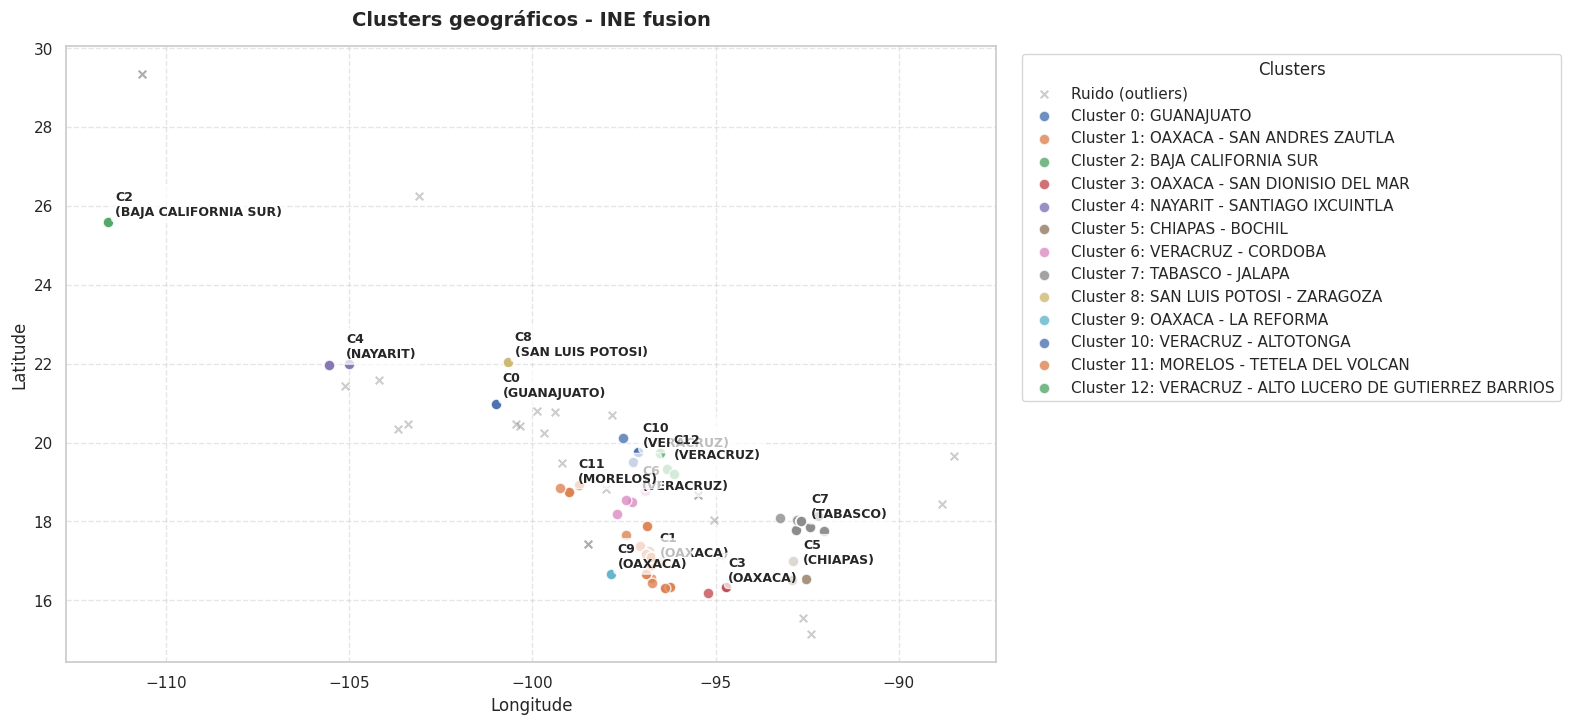

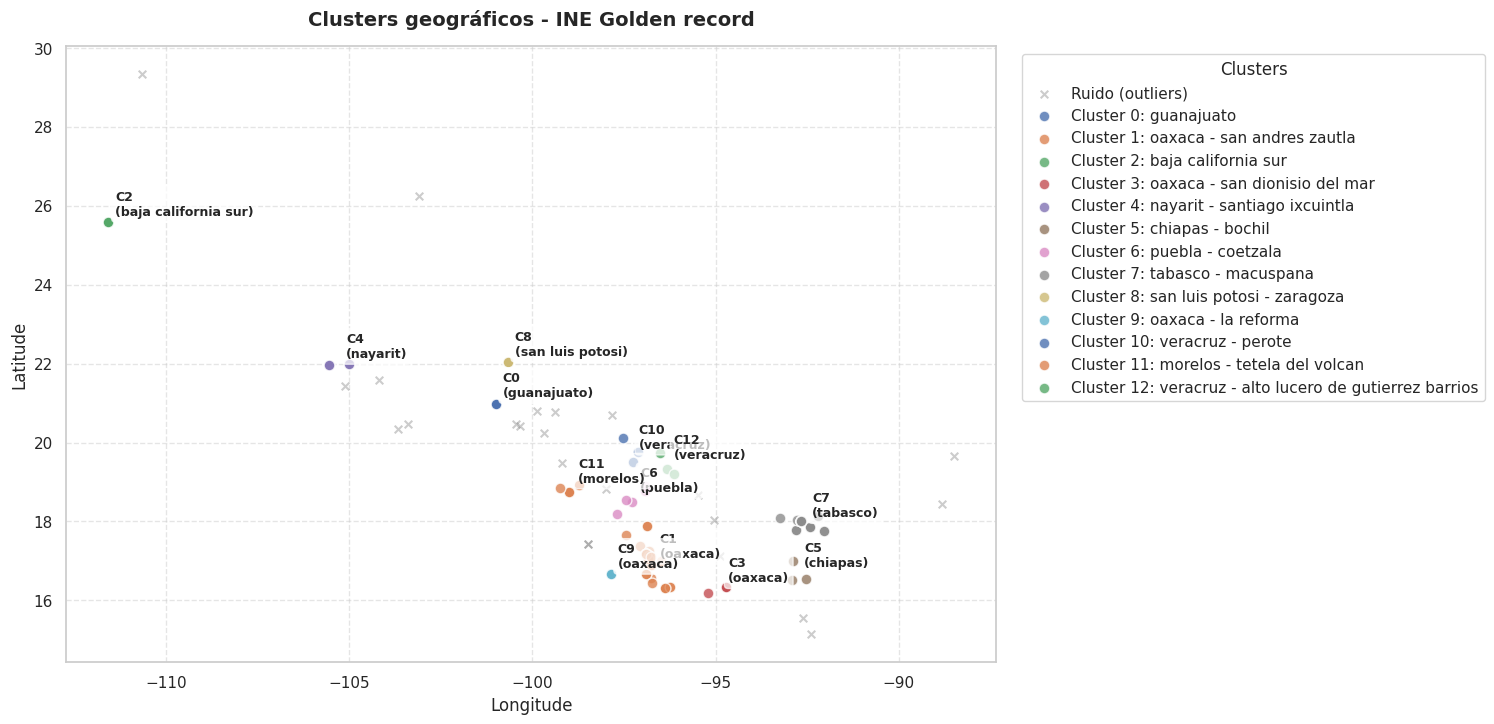

In [66]:
ine_fusion_geoclustering = cluster_geographically(
    ine_fusion_geo,
    plot_title='Clusters geográficos - INE fusion',
    save_plot=True
)
golden_g_geoclustering = cluster_geographically(
    golden_g_geo,
    plot_title='Clusters geográficos - INE Golden record',
    save_plot=True
)

### 4.2 Perfil estadístico integrado por estado

In [67]:
# Perfil estadístico por Estado
def pct_si(series):
    return (series.fillna('').astype(str).str.upper() == 'SI').mean()

perfil_base_estado = (
    matches_full
    .groupby(['estado_ine','vinculo_grupo_ine'])
    .agg(
        n_sanciones_ine   = ('idx_ine',        'nunique'),
        n_casos_banavim   = ('idx_bv',          'nunique'),
        edad_media_bv     = ('edad_bv',          'mean'),
        municipios_unicos = ('municipio_ine',    'nunique'),
    )
    .reset_index()
)
perfil_arma_estado = (
    matches_full
    .groupby(['estado_ine','vinculo_grupo_ine'])['Portaba Dicha Arma_bv']
    .apply(pct_si).reset_index()
    .rename(columns={'Portaba Dicha Arma_bv': 'pct_portaba_arma'})
)
perfil_alcohol_estado = (
    matches_full
    .groupby(['estado_ine','vinculo_grupo_ine'])['Droga_Alcohol_bv']
    .apply(pct_si).reset_index()
    .rename(columns={'Droga_Alcohol_bv': 'pct_alcohol'})
)
perfil_estado = (
    perfil_base_estado
    .merge(perfil_arma_estado,    on=['estado_ine','vinculo_grupo_ine'])
    .merge(perfil_alcohol_estado, on=['estado_ine','vinculo_grupo_ine'])
    .round(3)
    .sort_values('n_sanciones_ine', ascending=False)
)
print(f'Perfil por estado generado: {len(perfil_estado):,} grupos')
display(perfil_estado)

perfil_estado.to_csv(
    DATA_DIR / 'fusion_outputs' / 'perfil_estado_integrado.csv',
    index=False, encoding='utf-8-sig'
)
print('Guardado: perfil_estado_integrado.csv')

Perfil por estado generado: 12 grupos


,estado_ine,vinculo_grupo_ine,n_sanciones_ine,n_casos_banavim,edad_media_bv,municipios_unicos,pct_portaba_arma,pct_alcohol
4,OAXACA,PARES,9,10,31.784,3,0.000,0.0
3,OAXACA,JERARQUICA_SUBORDINACION,4,11,46.938,3,0.000,0.0
10,TABASCO,PARES,2,2,43.000,1,0.000,0.0
0,COAHUILA,PARES,1,1,28.000,1,0.000,0.0
2,MORELOS,JERARQUICA_SUBORDINACION,1,4,43.750,1,0.250,0.0
1,HIDALGO,JERARQUICA_SUBORDINACION,1,1,45.000,1,0.000,0.0
6,PUEBLA,PARES,1,1,50.000,1,1.000,0.0
5,PUEBLA,JERARQUICA_SUBORDINACION,1,2,41.000,1,0.500,0.0
7,QUINTANA ROO,OTRO,1,1255,37.254,1,0.023,0.0
8,SAN LUIS POTOSI,JERARQUICA_SUBORDINACION,1,1,47.000,1,0.000,0.0


Guardado: perfil_estado_integrado.csv
